# Use Case — Single-Parcel Heat Due Diligence for the Site Developer

**Who this is for**
Developers, owners, and their consultants evaluating **one site** before acquisition, entitlement, or design — plus the brokers, lenders, and design teams who need the same answer on a single parcel.

**The scenario**
You are under contract on a 3.3-acre downtown corner lot and have a short diligence window. You need a defensible read on the site's thermal exposure *before* you commit: how hot the parcel actually runs, how long it stays hot, why it is hot, and what that implies for cooling load, occupant comfort, and construction-phase worker safety. Nobody is going to stand on the lot with a sensor for a week.

This notebook takes a **parcel boundary** — not a point — and runs **every FortyGuard endpoint** against it, then assembles one client-ready report.

| # | Question | Layer |
|---|----------|-------|
| 1 | How hot does this parcel run, and how does that compare to the city? | heatmap (`tcm`) clipped to the parcel |
| 2 | How *long* does it stay hot? | heatmap (`exceedance`, `persistence`) |
| 3 | Why is it hot? | satellite segmentation — surface composition |
| 4 | What does the curb actually look like? | street-view segmentation |
| 5 | What does comfort look like hour by hour? | environmental parameters |
| 6 | What is the narrative a stakeholder can read? | heat-intelligence report |

---

### Two things that make parcel scale different from our other use cases

The three existing use-case notebooks take a **point list** over a **citywide AOI** and rank the points against each other. Neither of those moves works here, and the notebook is built around the difference:

**1. A parcel is smaller than a tile.** The heatmap's finest granularity is 60 m. This parcel is 140 m x 100 m, so it spans roughly four tiles. There is no meaningful "hot spot within the parcel" to find. Every parcel number below is therefore an **area-weighted mean** over the tiles the boundary actually overlaps — Step 4 — not a nearest-tile lookup.

**2. At parcel scale the snapshot barely varies — the duration metrics do.** Across the buffered AOI used here, daily-peak temperature spans about **0.9 °C**, while the same AOI spans **15 hours** of exceedance. Over the full citywide AOI the daily-peak spread is **5.9 °C**. So at this scale the temperature snapshot is close to flat and cannot separate good sites from bad ones — the *duration* layers (Step 5) and the *cause* layers (Steps 6-8) carry the signal. That is why the report leads with hours-above-threshold rather than degrees.

Because the snapshot is flat locally, the comparison that means something is **parcel vs. the whole city**, not parcel vs. its own block. Step 4 computes a citywide percentile from the bundled San Jose sample heatmap — no extra API credits.

---

> **AOI = parcel + buffer.** The heatmap runs over the parcel *plus* a `BUFFER_M` ring (default 500 m, about 1.2 km²) so there is a real map and a neighbourhood baseline to compare against. All parcel-level statistics are then clipped back to the boundary itself.

> **Runs live against the API, and caches.** Add your `FORTYGUARD_API_KEY` to `.env`. Every API step writes its raw response under `data/`; re-running reads the cache instead of re-billing. Set `REFRESH = True` in Setup to force fresh calls.

> **Bring your own parcel.** Drop any single-feature polygon GeoJSON in `data/` and point `PARCEL_GEOJSON` at it. Attributes are free-form — whatever is in `properties` is carried into the report. `data/` is git-ignored.

> **U.S. coverage only.** All endpoints serve U.S. locations. **Dates: 2021-01-01 to today.**

---

## Setup

### What you are doing
Loading configuration, the API client, the polling/caching helpers, and the small
local-metric geometry helpers used to buffer and clip the parcel.

### Why this matters
The repo ships no projection library (`pyproj`/`geopandas` are not dependencies),
so buffering in metres is done with a local equirectangular approximation around
the parcel centroid. Over a 1 km AOI that is accurate to well under a metre —
far below the 60 m tile size — and it keeps the notebook dependency-free.

In [1]:
import sys, pathlib, time as _time
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

import json, math
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Polygon, shape, mapping
from IPython.display import display

from fortyguard import FortyGuardClient
from fortyguard.exceptions import FortyGuardError

# ── configuration ──────────────────────────────────────────────────────────
PARCEL_FILE    = 'parcel_diridon_san_jose_sample.geojson'  # any 1-feature polygon
STUDY_DATE     = '2024-07-15'      # snapshot day (>= 2021-01-01, <= today)
STUDY_HOUR     = '14:00'           # design-peak afternoon
BUFFER_M       = 500               # context ring around the parcel
GRANULARITY_M  = 60                # finest the API offers — right call at this scale
REFRESH        = False             # True = ignore caches and re-bill every call

# Exposure-duration window (Step 5). filter_type=4 = range of days.
WINDOW_START   = '2024-07-12'
WINDOW_END     = '2024-07-18'

# Published thresholds the recommendations key off (Step 10) — no invented index.
NOAA_CAUTION_C   = 27.0   # NOAA heat-index "Caution" onset (80 F)
NOAA_EXTREME_C   = 32.0   # NOAA "Extreme Caution" onset (90 F)
OSHA_HIGH_C      = 32.2   # OSHA high-heat trigger (90 F)
CANOPY_TARGET    = 15.0   # % canopy — below this, USDA i-Tree planting is indicated
IMPERVIOUS_LIMIT = 60.0   # % building+road+sidewalk — above this, EPA cool-surface

# ── paths ──────────────────────────────────────────────────────────────────
DATA           = ROOT / 'data'
PARCEL_GEOJSON = DATA / PARCEL_FILE
HEATMAP_DIR    = DATA / 'heatmaps'
SAT_SEG_DIR    = DATA / 'satellite'
STREET_SEG_DIR = DATA / 'street_view'
ENV_DIR        = DATA / 'env_params'
PARCEL_DIR     = DATA / 'parcel'
for d in (HEATMAP_DIR, SAT_SEG_DIR, STREET_SEG_DIR, ENV_DIR, PARCEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

SLUG = PARCEL_GEOJSON.stem.replace('_sample', '')

# Citywide baseline for the percentile in Step 4. Optional — produced by any of the
# other use-case notebooks. If absent, the percentile is skipped, nothing else breaks.
CITY_BASELINE = HEATMAP_DIR / f'heatmap_san_jose_{STUDY_DATE}_live.geojson'

OUTPUTS_ROOT = ROOT / 'outputs' / f'{SLUG}_{STUDY_DATE}'
(OUTPUTS_ROOT / 'maps').mkdir(parents=True, exist_ok=True)

# ── client ─────────────────────────────────────────────────────────────────
try:
    client = FortyGuardClient()
    HAVE_API = True
except FortyGuardError as exc:
    client, HAVE_API = None, False
    print(f'[no API key] live calls disabled, cache-only: {exc}')


# ── polling helper (same contract as the other use-case notebooks) ─────────
def submit_and_wait_quiet(client_method, label, *, poll_interval=8.0,
                          initial_delay=3.0, transient_403_retries=4,
                          failure_retries=2, timeout=900.0,
                          skip_on_failure=False, **kwargs):
    """Submit an async task and poll quietly. Two lines of output per call.

    The status endpoint can return 404/403 for a few seconds right after submit
    while the activity propagates; those are retried rather than raised. A
    task-level backend failure is re-submitted up to failure_retries times.
    With skip_on_failure=True the call returns None instead of raising, so an
    optional layer (street view has no imagery everywhere) can be skipped.
    """
    def _giveup(exc):
        if skip_on_failure:
            print(f'  skipped: {label} unavailable ({type(exc).__name__}).')
            return None
        print(f'  FAILED: {label}: {exc}')
        raise exc

    for submit_attempt in range(failure_retries + 1):
        activity_id = client_method(wait=False, **kwargs)
        print(f'Submitted {label} -> {activity_id}')
        if initial_delay:
            _time.sleep(initial_delay)
        for attempt in range(transient_403_retries + 1):
            try:
                result = client.wait_for(activity_id, poll_interval=poll_interval,
                                         timeout=timeout)
                print(f'  done: {label}')
                return {'activity_id': activity_id, 'result': result}
            except FortyGuardError as exc:
                msg = str(exc)
                is_403 = '-> 403' in msg or 'Unauthorized access' in msg
                is_task_failure = ' failed:' in msg and '-> ' not in msg
                if is_403 and attempt < transient_403_retries:
                    back_off = 5 * (attempt + 1)
                    print(f'  status 403 (transient); retry in {back_off}s')
                    _time.sleep(back_off)
                    continue
                if is_task_failure and submit_attempt < failure_retries:
                    back_off = 5 * (submit_attempt + 1)
                    print(f'  task failed (transient); re-submitting in {back_off}s')
                    _time.sleep(back_off)
                    break
                return _giveup(exc)
            except Exception as exc:
                return _giveup(exc)
    return _giveup(RuntimeError(f'{label}: exhausted all submit attempts'))


def cached_or_live(cache_path, label, client_method, **kwargs):
    """Read a cached raw response, or call the API once and cache it.

    The other use-case notebooks split this into paired "Step Na (live) /
    Step Nb (cached)" cells. One helper gives the same offline-replay behaviour
    without duplicating every step. Delete the file under data/ — or set
    REFRESH = True — to force a fresh, billable call.
    """
    cache_path = pathlib.Path(cache_path)
    if not REFRESH and cache_path.exists():
        print(f'cached: {label} <- {cache_path.relative_to(ROOT)}')
        return json.loads(cache_path.read_text())
    if not HAVE_API:
        raise RuntimeError(
            f'{label}: no cache at {cache_path.relative_to(ROOT)} and no API key. '
            f'Add FORTYGUARD_API_KEY to .env, or copy a cached response into place.'
        )
    resp = submit_and_wait_quiet(client_method, label, **kwargs)
    if resp is None:
        return None
    result = resp['result']
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(json.dumps(result))
    print(f'  saved -> {cache_path.relative_to(ROOT)}')
    return result


# ── local-metric geometry (no pyproj) ──────────────────────────────────────
M_PER_DEG_LAT = 111_132.0

def m_per_deg_lon(lat):
    return 111_320.0 * math.cos(math.radians(lat))

def to_local_m(poly, lat0, lon0):
    """WGS84 polygon -> metres, in a local plane centred on (lat0, lon0)."""
    k = m_per_deg_lon(lat0)
    return Polygon([((x - lon0) * k, (y - lat0) * M_PER_DEG_LAT)
                    for x, y in poly.exterior.coords])

def to_wgs84(poly, lat0, lon0):
    """Inverse of to_local_m."""
    k = m_per_deg_lon(lat0)
    return Polygon([(lon0 + x / k, lat0 + y / M_PER_DEG_LAT)
                    for x, y in poly.exterior.coords])


# ── shared colour ramp (matches the other use-case notebooks) ─────────────
TCM_COLORS = [
    '#2983ba', '#5aa4b2', '#88c4aa', '#b3e0a6', '#d1ecb0', '#f0f9ba',
    '#fff0ae', '#fed38c', '#fdb56a', '#f3854e', '#e54f35', '#d7191c',
]
TCM_CMAP = LinearSegmentedColormap.from_list('tcm', TCM_COLORS, N=256)

def temp_color(t, lo, hi):
    if t is None or lo is None or hi is None or hi == lo:
        return TCM_COLORS[0]
    frac = max(0.0, min(1.0, (float(t) - lo) / (hi - lo)))
    return TCM_COLORS[min(int(frac * len(TCM_COLORS)), len(TCM_COLORS) - 1)]

print(f'STUDY_DATE={STUDY_DATE}  BUFFER_M={BUFFER_M}  GRANULARITY_M={GRANULARITY_M}')
print(f'window {WINDOW_START} .. {WINDOW_END}   REFRESH={REFRESH}')
print(f'outputs -> {OUTPUTS_ROOT.relative_to(ROOT)}')

STUDY_DATE=2024-07-15  BUFFER_M=500  GRANULARITY_M=60
window 2024-07-12 .. 2024-07-18   REFRESH=False
outputs -> outputs/parcel_diridon_san_jose_2024-07-15


## Step 1 — Load the parcel boundary and build the AOI

### What you are doing
Reading the parcel polygon, measuring it, and growing a `BUFFER_M` context ring
around it to use as the heatmap AOI.

### Why this matters
This is the step that separates this notebook from the point-based use cases. The
parcel is a real boundary with real area, so it can be *measured* (acres, frontage,
extent) and later *clipped against* — a point can do neither. The buffer exists
because a parcel-only AOI would return one to four tiles, which is not a map. The
mitred buffer keeps the AOI a clean block rather than rounding the corners.

In [2]:
parcel_fc = json.loads(PARCEL_GEOJSON.read_text())
feat      = parcel_fc['features'][0]
PARCEL    = shape(feat['geometry'])
ATTRS     = dict(feat.get('properties') or {})

if PARCEL.geom_type != 'Polygon':
    raise ValueError(f'Expected a Polygon parcel boundary, got {PARCEL.geom_type}.')

CX, CY = PARCEL.centroid.x, PARCEL.centroid.y            # lon, lat

# Measure in the local metric plane.
parcel_m   = to_local_m(PARCEL, CY, CX)
AREA_M2    = parcel_m.area
AREA_ACRES = AREA_M2 / 4046.8564224
xs = [p[0] for p in parcel_m.exterior.coords]
ys = [p[1] for p in parcel_m.exterior.coords]
EXTENT_X, EXTENT_Y = max(xs) - min(xs), max(ys) - min(ys)
PERIMETER_M = parcel_m.length

# AOI = parcel buffered by BUFFER_M (mitred join keeps square corners).
aoi_m   = parcel_m.buffer(BUFFER_M, join_style=2)
AOI     = to_wgs84(aoi_m, CY, CX)
AOI_KM2 = aoi_m.area / 1e6
AOI_FC  = {'type': 'FeatureCollection',
           'features': [{'type': 'Feature', 'properties': {},
                         'geometry': mapping(AOI)}]}

PARCEL_NAME = ATTRS.get('name') or PARCEL_GEOJSON.stem
PARCEL_ID   = ATTRS.get('parcel_id') or '-'

print(f'{PARCEL_NAME}  ({PARCEL_ID})')
for k in ('address', 'city', 'state', 'zoning', 'proposed_use', 'proposed_gsf', 'status'):
    if ATTRS.get(k) not in (None, ''):
        print(f'  {k:14}: {ATTRS[k]}')
print()
print(f'  centroid      : {CY:.6f}, {CX:.6f}')
print(f'  lot area      : {AREA_M2:,.0f} m2   ({AREA_ACRES:.2f} acres)')
print(f'  extent        : {EXTENT_X:.0f} m x {EXTENT_Y:.0f} m   perimeter {PERIMETER_M:.0f} m')
print(f'  vertices      : {len(PARCEL.exterior.coords) - 1}')
print()
print(f'  AOI           : parcel + {BUFFER_M} m  ->  {AOI_KM2:.3f} km2')
print(f'  expected tiles: ~{aoi_m.area / (GRANULARITY_M ** 2):,.0f} at {GRANULARITY_M} m')
print(f'  parcel spans  : ~{AREA_M2 / (GRANULARITY_M ** 2):.1f} tiles '
      f'-- too few to rank internally, hence the area-weighted clip in Step 4')

Diridon Gateway Site  (APN-259-27-014)
  address       : W Santa Clara St & Cahill St
  city          : San Jose
  state         : CA
  zoning        : DC — Downtown Commercial
  proposed_use  : Mixed-use office / residential
  proposed_gsf  : 420000
  status        : Under evaluation

  centroid      : 37.330487, -121.900023
  lot area      : 13,525 m2   (3.34 acres)
  extent        : 140 m x 100 m   perimeter 462 m
  vertices      : 5

  AOI           : parcel + 500 m  ->  1.202 km2
  expected tiles: ~334 at 60 m
  parcel spans  : ~3.8 tiles -- too few to rank internally, hence the area-weighted clip in Step 4


## Step 2 — See the parcel in its context

### What you are doing
Drawing the parcel boundary and the buffered AOI on a slippy map.

### Why this matters
Sanity check before spending credits: if the boundary is in the wrong place, has
the wrong winding, or the buffer is the wrong size, you want to see it now rather
than after six API calls. This map also becomes the locator figure in the report.

In [3]:
m_context = folium.Map(location=[CY, CX], zoom_start=16, tiles='CartoDB positron')

folium.GeoJson(
    mapping(AOI),
    name=f'AOI (parcel + {BUFFER_M} m)',
    style_function=lambda _: {'color': '#0E4A8A', 'weight': 2, 'fillOpacity': 0.04,
                              'dashArray': '6,4'},
).add_to(m_context)

folium.GeoJson(
    mapping(PARCEL),
    name='Parcel boundary',
    style_function=lambda _: {'color': '#d7191c', 'weight': 3, 'fillColor': '#d7191c',
                              'fillOpacity': 0.25},
    tooltip=folium.Tooltip(
        f'<b>{PARCEL_NAME}</b><br>{PARCEL_ID}<br>'
        f'{AREA_ACRES:.2f} acres ({AREA_M2:,.0f} m2)'
    ),
).add_to(m_context)

folium.Marker(
    [CY, CX],
    tooltip='Parcel centroid — anchor for satellite / street-view / env-params',
    icon=folium.Icon(color='red', icon='crosshairs', prefix='fa'),
).add_to(m_context)

folium.LayerControl(collapsed=False).add_to(m_context)
display(m_context)

## Step 3 — Heat layer over the AOI

### What you are doing
One `tcm` heatmap over the buffered AOI for `STUDY_DATE`, at 60 m.
`filter_type=3` (single day) returns a per-tile daily aggregate — min, mean, and
max temperature in °C — rather than an hourly series.

### Why this matters
This is the base layer everything else is measured against. Note what the summary
card shows: across the whole AOI the daily-peak spread is well under a degree.
That flatness is the honest result at this scale, and it is exactly why the report
does not lean on the snapshot alone.

In [4]:
HEATMAP_CACHE = HEATMAP_DIR / f'heatmap_{SLUG}_{STUDY_DATE}_tcm.json'

hm = cached_or_live(
    HEATMAP_CACHE, f'heatmap tcm {STUDY_DATE}', client.create_heatmap if HAVE_API else None,
    polygon_aoi=AOI_FC, start_date=STUDY_DATE, start_time=STUDY_HOUR,
    filter_type=3, granularity=GRANULARITY_M,
)

map_data = hm.get('map_data') or {}
features = map_data.get('features', []) if isinstance(map_data, dict) else []

# Normalize to (polygon, mean_c, peak_c, min_c).
tiles = []
for f in features:
    p = f.get('properties') or {}
    tiles.append((
        shape(f['geometry']),
        p.get('average_temperature'),
        p.get('max_temperature'),
        p.get('min_temperature'),
    ))

aoi_peaks = [t[2] for t in tiles if t[2] is not None]
aoi_means = [t[1] for t in tiles if t[1] is not None]
print(f'{len(tiles):,} tiles')
print(f'daily peak  : {min(aoi_peaks):.2f} .. {max(aoi_peaks):.2f} °C '
      f'(spread {max(aoi_peaks) - min(aoi_peaks):.2f} °C, mean {np.mean(aoi_peaks):.2f})')
print(f'daily mean  : {min(aoi_means):.2f} .. {max(aoi_means):.2f} °C '
      f'(spread {max(aoi_means) - min(aoi_means):.2f} °C)')

cached: heatmap tcm 2024-07-15 <- data/heatmaps/heatmap_parcel_diridon_san_jose_2024-07-15_tcm.json
329 tiles
daily peak  : 26.71 .. 27.61 °C (spread 0.90 °C, mean 27.30)
daily mean  : 20.44 .. 20.86 °C (spread 0.43 °C)


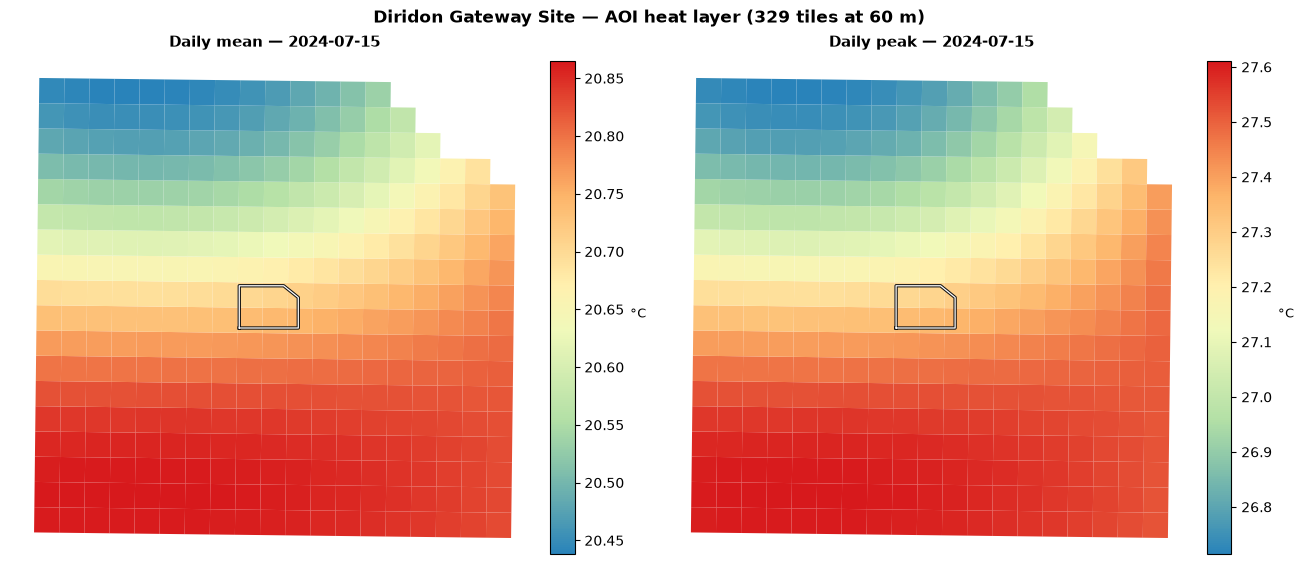

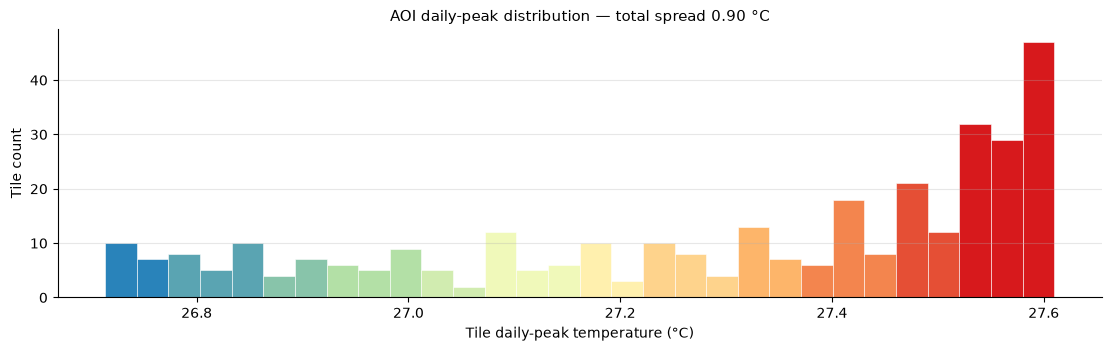

In [5]:
# AOI map with the parcel outlined on top — the core locator figure for the report.
def draw_aoi_map(ax, values, title, cmap=TCM_CMAP, units='°C'):
    """Tile-by-tile choropleth of the AOI with the parcel boundary overlaid."""
    vals = [v for v in values if v is not None]
    lo, hi = min(vals), max(vals)
    for (poly, *_), v in zip(tiles, values):
        if v is None:
            continue
        frac = 0.0 if hi == lo else (v - lo) / (hi - lo)
        ax.fill(*poly.exterior.xy, color=cmap(frac), linewidth=0)
    ax.plot(*PARCEL.exterior.xy, color='#111', linewidth=2.4, zorder=5)
    ax.plot(*PARCEL.exterior.xy, color='#fff', linewidth=0.9, zorder=6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_aspect(1 / math.cos(math.radians(CY)))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=lo, vmax=hi))
    cb = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label(units, rotation=0, labelpad=10, fontsize=9)
    return lo, hi


fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), constrained_layout=True)
draw_aoi_map(axes[0], [t[1] for t in tiles], f'Daily mean — {STUDY_DATE}')
draw_aoi_map(axes[1], [t[2] for t in tiles], f'Daily peak — {STUDY_DATE}')
fig.suptitle(f'{PARCEL_NAME} — AOI heat layer ({len(tiles):,} tiles at {GRANULARITY_M} m)',
             fontsize=12.5, fontweight='bold')
plt.show()

fig_hist, ax = plt.subplots(figsize=(11, 3.4), constrained_layout=True)
_, edges, patches = ax.hist(aoi_peaks, bins=30, edgecolor='white', linewidth=0.4)
lo, hi = min(aoi_peaks), max(aoi_peaks)
for patch, e_lo, e_hi in zip(patches, edges[:-1], edges[1:]):
    patch.set_facecolor(temp_color((e_lo + e_hi) / 2, lo, hi))
ax.set_xlabel('Tile daily-peak temperature (°C)')
ax.set_ylabel('Tile count')
ax.set_title(f'AOI daily-peak distribution — total spread {hi - lo:.2f} °C', fontsize=11)
ax.grid(axis='y', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
plt.show()

## Step 4 — Clip the heat layer to the parcel boundary

### What you are doing
Computing the parcel's exposure as an **area-weighted mean** of every tile the
boundary overlaps, weighted by the overlap area, then placing that number against
the AOI and against the whole city.

### Why this matters
This is the methodological core of a parcel workflow. A point-based notebook asks
"which tile is this point in?" — fine for a bus stop, wrong for a 3.3-acre lot
that straddles four tiles, because it silently throws away three of them and the
answer flips depending on where the centroid happens to land. Area-weighting uses
every tile in proportion to how much of the parcel it actually covers, so the
number is stable, reproducible, and defensible in a diligence memo.

The citywide percentile comes from the bundled San Jose sample heatmap if it is
present — **no additional API credits**. Local context is nearly flat, so the
citywide frame is what carries meaning.

In [8]:
def clip_to_parcel(polys, values, parcel_poly):
    """Area-weighted mean of tile `values` over `parcel_poly`.

    Returns (weighted_mean, coverage_fraction, contributing_tiles). Weights are
    intersection areas in degrees^2 — all tiles are locally the same size, so the
    ratios are what matter and the unit cancels out.
    """
    num = den = 0.0
    parts = []
    for poly, v in zip(polys, values):
        if v is None:
            continue
        inter = poly.intersection(parcel_poly)
        if inter.is_empty:
            continue
        w = inter.area
        if w <= 0:
            continue
        num += w * float(v)
        den += w
        parts.append({'value': float(v), 'weight': w})
    if den == 0:
        return None, 0.0, []
    for p in parts:
        p['share_pct'] = 100.0 * p['weight'] / den
    parts.sort(key=lambda p: -p['weight'])
    return num / den, den / parcel_poly.area, parts


polys = [t[0] for t in tiles]
PARCEL_PEAK, cov, peak_parts = clip_to_parcel(polys, [t[2] for t in tiles], PARCEL)
PARCEL_MEAN, _,   _          = clip_to_parcel(polys, [t[1] for t in tiles], PARCEL)
PARCEL_MIN,  _,   _          = clip_to_parcel(polys, [t[3] for t in tiles], PARCEL)
PARCEL_SWING = None if None in (PARCEL_PEAK, PARCEL_MIN) else PARCEL_PEAK - PARCEL_MIN

print(f'Parcel overlaps {len(peak_parts)} tiles; boundary coverage {cov * 100:.1f}%')
for p in peak_parts:
    print(f'    tile peak {p["value"]:6.2f} °C   weight {p["share_pct"]:5.1f}%')
print()
print(f'  parcel daily peak  : {PARCEL_PEAK:.2f} °C   (area-weighted)')
print(f'  parcel daily mean  : {PARCEL_MEAN:.2f} °C')
print(f'  parcel daily min   : {PARCEL_MIN:.2f} °C')
print(f'  diurnal swing      : {PARCEL_SWING:.2f} °C')

# --- where the parcel sits within its own AOI ---
aoi_sorted = sorted(aoi_peaks)
AOI_PCT = 100.0 * sum(1 for v in aoi_sorted if v < PARCEL_PEAK) / len(aoi_sorted)
AOI_DELTA = PARCEL_PEAK - float(np.median(aoi_sorted))
print()
print(f'  vs AOI  : {AOI_PCT:5.1f}th percentile   '
      f'({AOI_DELTA:+.2f} °C vs AOI median)  [AOI spread is only '
      f'{max(aoi_peaks) - min(aoi_peaks):.2f} °C -- weak signal]')

# --- where the parcel sits citywide (free: uses the bundled sample heatmap) ---
CITY_PCT = CITY_DELTA = None
if CITY_BASELINE.exists():
    city = json.loads(CITY_BASELINE.read_text())
    city_peaks = sorted(
        f['properties']['max_temperature'] for f in city.get('features', [])
        if (f.get('properties') or {}).get('max_temperature') is not None
    )
    if city_peaks:
        CITY_PCT = 100.0 * sum(1 for v in city_peaks if v < PARCEL_PEAK) / len(city_peaks)
        CITY_DELTA = PARCEL_PEAK - float(np.median(city_peaks))
        print(f'  vs city : {CITY_PCT:5.1f}th percentile   '
              f'({CITY_DELTA:+.2f} °C vs citywide median)  '
              f'[{len(city_peaks):,} tiles, spread '
              f'{city_peaks[-1] - city_peaks[0]:.2f} °C -- real signal]')
else:
    print(f'  vs city : skipped, no baseline at {CITY_BASELINE.relative_to(ROOT)}')
    print('            (run any other use-case notebook once to produce it)')

Parcel overlaps 6 tiles; boundary coverage 100.0%
    tile peak  27.28 °C   weight  22.9%
    tile peak  27.27 °C   weight  21.4%
    tile peak  27.35 °C   weight  20.9%
    tile peak  27.35 °C   weight  19.6%
    tile peak  27.36 °C   weight   8.8%
    tile peak  27.29 °C   weight   6.4%

  parcel daily peak  : 27.31 °C   (area-weighted)
  parcel daily mean  : 20.72 °C
  parcel daily min   : 16.34 °C
  diurnal swing      : 10.97 °C

  vs AOI  :  41.9th percentile   (-0.09 °C vs AOI median)  [AOI spread is only 0.90 °C -- weak signal]
  vs city :  47.3th percentile   (-0.04 °C vs citywide median)  [16,222 tiles, spread 5.85 °C -- real signal]


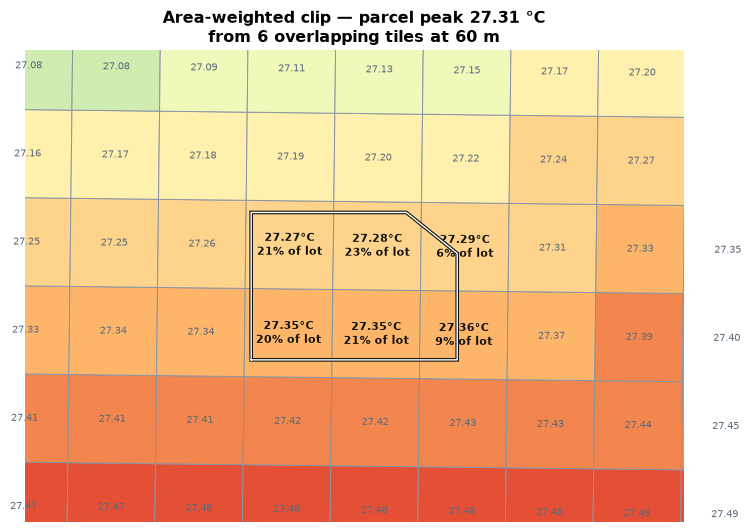

In [9]:
# Zoomed clip diagram — the parcel against the tiles it actually overlaps.
fig, ax = plt.subplots(figsize=(7.4, 6.2), constrained_layout=True)
pk = [t[2] for t in tiles]
lo, hi = min(v for v in pk if v is not None), max(v for v in pk if v is not None)

minx, miny, maxx, maxy = PARCEL.bounds
pad_x = (maxx - minx) * 1.1
pad_y = (maxy - miny) * 1.1
for (poly, _mean, peak, _mn) in tiles:
    if peak is None:
        continue
    b = poly.bounds
    if b[2] < minx - pad_x or b[0] > maxx + pad_x or b[3] < miny - pad_y or b[1] > maxy + pad_y:
        continue
    ax.fill(*poly.exterior.xy, color=temp_color(peak, lo, hi),
            edgecolor='#8895a4', linewidth=0.7)
    c = poly.centroid
    if poly.intersects(PARCEL):
        share = 100.0 * poly.intersection(PARCEL).area / PARCEL.area
        ax.text(c.x, c.y, f'{peak:.2f}°C\n{share:.0f}% of lot', ha='center', va='center',
                fontsize=8, fontweight='bold', color='#111')
    else:
        ax.text(c.x, c.y, f'{peak:.2f}', ha='center', va='center',
                fontsize=7.5, color='#5a6b7b')

ax.fill(*PARCEL.exterior.xy, facecolor='none', edgecolor='#111', linewidth=2.6, zorder=5)
ax.plot(*PARCEL.exterior.xy, color='#fff', linewidth=1.0, zorder=6)
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_aspect(1 / math.cos(math.radians(CY)))
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title(f'Area-weighted clip — parcel peak {PARCEL_PEAK:.2f} °C\n'
             f'from {len(peak_parts)} overlapping tiles at {GRANULARITY_M} m',
             fontsize=11.5, fontweight='bold')
fig_clip = fig
plt.show()

## Step 5 — Exposure duration: how long does the parcel stay hot?

### What you are doing
Two more heatmaps over the same AOI, this time across a multi-day window
(`filter_type=4`): **exceedance** — how many hours each cell spends above
`NOAA_CAUTION_C` — and **persistence** — the longest unbroken run of such hours.
Both are clipped to the parcel with the same area-weighted method as Step 4.

### Why this matters
This is the section a diligence memo is actually built on, for two reasons.

**It is what mechanical and safety decisions key off.** Peak temperature sizes a
chiller; *hours above a threshold* drives annual cooling energy, and *consecutive*
hours drives whether a slab or façade ever sheds the heat it absorbed overnight —
and whether a construction crew hits an OSHA high-heat trigger.

**It is the only layer with usable contrast at this scale.** Recall Step 3: the
daily-peak snapshot spans well under a degree across the whole AOI. Exceedance
over the same AOI spans on the order of 15 hours — a 1.5x range between the
coolest and hottest cells. The duration layers can separate this parcel from its
neighbours; the snapshot cannot.

In [10]:
def analytic_layer(kind, threshold, direction='above'):
    """Run (or load) one analysis heatmap and clip it to the parcel."""
    cache = HEATMAP_DIR / f'heatmap_{SLUG}_{WINDOW_START}_{WINDOW_END}_{kind}.json'
    res = cached_or_live(
        cache, f'heatmap {kind} {WINDOW_START}..{WINDOW_END}',
        client.create_heatmap if HAVE_API else None,
        polygon_aoi=AOI_FC, start_date=WINDOW_START, end_date=WINDOW_END,
        filter_type=4, granularity=GRANULARITY_M,
        analytic_type=kind, threshold=threshold, direction=direction,
    )
    md_ = res.get('map_data') or {}
    feats = md_.get('features', []) if isinstance(md_, dict) else []
    p_ = [shape(f['geometry']) for f in feats]
    v_ = [(f.get('properties') or {}).get('value') for f in feats]
    parcel_val, coverage, _parts = clip_to_parcel(p_, v_, PARCEL)
    stats = res.get('stats_data') or {}
    return {'kind': kind, 'polys': p_, 'values': v_, 'parcel': parcel_val,
            'coverage': coverage, 'stats': stats,
            'units': stats.get('units', 'hour'), 'threshold': threshold}


WINDOW_HOURS = (
    (pd.Timestamp(WINDOW_END) - pd.Timestamp(WINDOW_START)).days + 1
) * 24

EXC = analytic_layer('exceedance',  NOAA_CAUTION_C)
PER = analytic_layer('persistence', NOAA_CAUTION_C)

exc_vals = [v for v in EXC['values'] if v is not None]
per_vals = [v for v in PER['values'] if v is not None]

print()
print(f'Window {WINDOW_START} .. {WINDOW_END}  =  {WINDOW_HOURS} hours, '
      f'threshold {NOAA_CAUTION_C:g} °C (NOAA Caution onset)')
print(f'  exceedance  parcel {EXC["parcel"]:.1f} h  '
      f'({100 * EXC["parcel"] / WINDOW_HOURS:.0f}% of the window)   '
      f'AOI {min(exc_vals):.1f}..{max(exc_vals):.1f} h '
      f'(spread {max(exc_vals) - min(exc_vals):.1f} h)')
print(f'  persistence parcel {PER["parcel"]:.1f} h consecutive        '
      f'AOI {min(per_vals):.1f}..{max(per_vals):.1f} h')

EXC_PCT = 100.0 * sum(1 for v in exc_vals if v < EXC['parcel']) / len(exc_vals)
print()
print(f'  the parcel sits at the {EXC_PCT:.0f}th percentile of its own AOI on '
      f'exceedance -- a ranking the snapshot could not produce')

cached: heatmap exceedance 2024-07-12..2024-07-18 <- data/heatmaps/heatmap_parcel_diridon_san_jose_2024-07-12_2024-07-18_exceedance.json
cached: heatmap persistence 2024-07-12..2024-07-18 <- data/heatmaps/heatmap_parcel_diridon_san_jose_2024-07-12_2024-07-18_persistence.json

Window 2024-07-12 .. 2024-07-18  =  168 hours, threshold 27 °C (NOAA Caution onset)
  exceedance  parcel 35.6 h  (21% of the window)   AOI 25.5..40.7 h (spread 15.2 h)
  persistence parcel 6.5 h consecutive        AOI 2.1..8.7 h

  the parcel sits at the 43th percentile of its own AOI on exceedance -- a ranking the snapshot could not produce


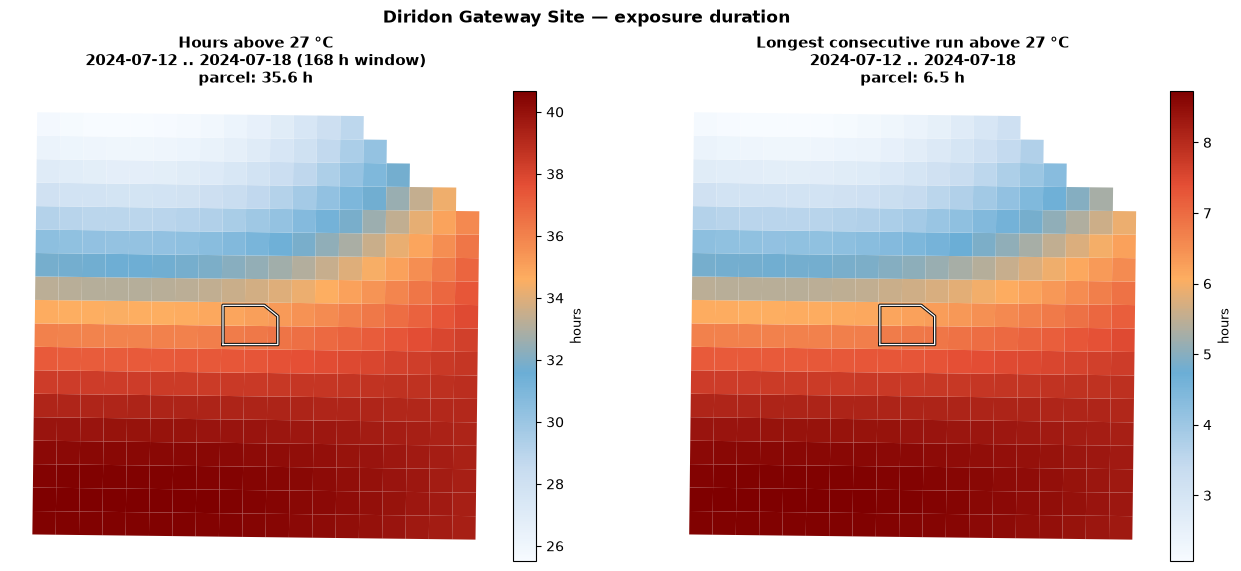

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), constrained_layout=True)
HOURS_CMAP = LinearSegmentedColormap.from_list(
    'hours', ['#f7fbff', '#c6dbef', '#6baed6', '#fdae61', '#e54f35', '#7f0000'], N=256)

for ax, layer, title in (
    (axes[0], EXC, f'Hours above {NOAA_CAUTION_C:g} °C\n{WINDOW_START} .. {WINDOW_END} '
                   f'({WINDOW_HOURS} h window)'),
    (axes[1], PER, f'Longest consecutive run above {NOAA_CAUTION_C:g} °C\n'
                   f'{WINDOW_START} .. {WINDOW_END}'),
):
    vals = [v for v in layer['values'] if v is not None]
    lo, hi = min(vals), max(vals)
    for poly, v in zip(layer['polys'], layer['values']):
        if v is None:
            continue
        ax.fill(*poly.exterior.xy, color=HOURS_CMAP(0 if hi == lo else (v - lo) / (hi - lo)),
                linewidth=0)
    ax.plot(*PARCEL.exterior.xy, color='#111', linewidth=2.4, zorder=5)
    ax.plot(*PARCEL.exterior.xy, color='#fff', linewidth=0.9, zorder=6)
    ax.set_title(f'{title}\nparcel: {layer["parcel"]:.1f} h',
                 fontsize=10.5, fontweight='bold')
    ax.set_aspect(1 / math.cos(math.radians(CY)))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=HOURS_CMAP, norm=plt.Normalize(vmin=lo, vmax=hi))
    cb = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label('hours', fontsize=9)

fig.suptitle(f'{PARCEL_NAME} — exposure duration', fontsize=12.5, fontweight='bold')
fig_duration = fig
plt.show()

## Step 6 — Why is it hot? Surface composition from satellite

### What you are doing
Satellite land-cover segmentation on the parcel centroid: the share of the tile
that is building, road, sidewalk, tree, and plant.

### Why this matters
The heat layers say *how much*; this says *what to do about it*. Impervious
building-and-pavement fraction is the lever a developer actually controls at
design stage — roof albedo, paving specification, and planting are all decided
long before a chiller is sized. A site that is 70% impervious with 5% canopy has
a different remedy from one that is already shaded and simply sits in a hot
district.

> **Scale caveat, stated honestly:** the satellite endpoint segments a tile
> centred on the point you give it, not the parcel polygon. At `GRANULARITY_M`
> the footprint is close to the parcel but not clipped to it, so treat these
> shares as *site-vicinity* composition rather than a parcel-exact take-off.

In [12]:
import base64, io
from PIL import Image as PILImage

def decode_b64(b64):
    """Base64 (optionally a 1-element list or a data: URI) -> PIL image."""
    if not b64:
        return None
    if isinstance(b64, list):
        b64 = b64[0] if b64 else None
    if not b64:
        return None
    if isinstance(b64, str) and b64.startswith('data:'):
        b64 = b64.split(',', 1)[1]
    try:
        return PILImage.open(io.BytesIO(base64.b64decode(b64)))
    except Exception:
        return None


SAT = cached_or_live(
    SAT_SEG_DIR / f'satellite_{SLUG}_{STUDY_DATE}.json',
    'satellite segmentation', client.satellite_segmentation if HAVE_API else None,
    latitude=CY, longitude=CX, start_date=STUDY_DATE, start_time=STUDY_HOUR,
    filter_type=3, granularity=GRANULARITY_M, skip_on_failure=True,
)

SEGMENTS, SAT_IMGS, SAT_LEGEND = {}, {}, {}
if SAT:
    seg = SAT.get('segmentation') or {}
    SEGMENTS   = {k: float(v) for k, v in (seg.get('segments') or {}).items()}
    SAT_LEGEND = seg.get('image_legend') or {}
    SAT_IMGS   = {'original': decode_b64(SAT.get('original_image')
                                         or SAT.get('orignal_image')),
                  'segmented': decode_b64(seg.get('image_content'))}
    print(f'imagery year: {SAT.get("image_year", "n/a")}')

def _share(*names):
    return sum(v for k, v in SEGMENTS.items()
               if any(n in k.lower() for n in names))

IMPERVIOUS_PCT = _share('building', 'road', 'route', 'sidewalk', 'pavement')
CANOPY_PCT     = _share('tree')
VEG_PCT        = _share('tree', 'plant', 'grass', 'vegetation')

for k, v in sorted(SEGMENTS.items(), key=lambda kv: -kv[1]):
    print(f'  {k:24}: {v:5.2f}%')
print()
print(f'  impervious (bldg+road+walk): {IMPERVIOUS_PCT:5.2f}%   '
      f'[EPA cool-surface trigger > {IMPERVIOUS_LIMIT:g}%]')
print(f'  tree canopy                : {CANOPY_PCT:5.2f}%   '
      f'[USDA i-Tree trigger < {CANOPY_TARGET:g}%]')
print(f'  all vegetation             : {VEG_PCT:5.2f}%')

cached: satellite segmentation <- data/satellite/satellite_parcel_diridon_san_jose_2024-07-15.json
imagery year: 2026
  others                  : 49.95%
  building                : 26.94%
  earth, ground           : 20.88%
  tree                    :  1.63%
  plant                   :  0.60%

  impervious (bldg+road+walk): 26.94%   [EPA cool-surface trigger > 60%]
  tree canopy                :  1.63%   [USDA i-Tree trigger < 15%]
  all vegetation             :  2.23%


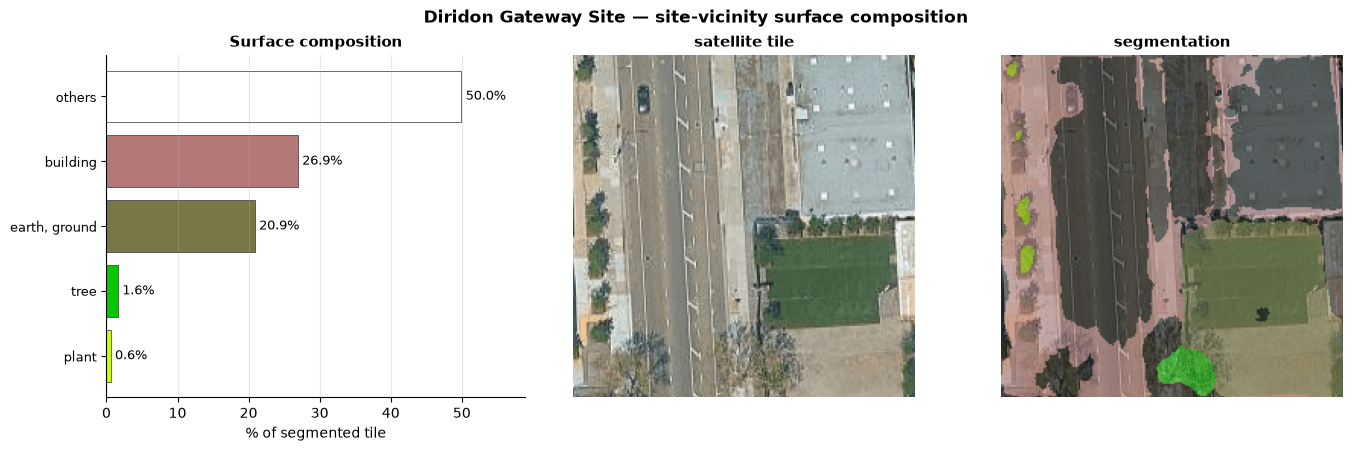

In [13]:
fig_sat = None
if SEGMENTS:
    items   = sorted(SEGMENTS.items(), key=lambda kv: -kv[1])
    labels  = [k for k, _ in items]
    vals    = [v for _, v in items]
    cols    = ['#%02x%02x%02x' % tuple(SAT_LEGEND[k][:3])
               if k in SAT_LEGEND and len(SAT_LEGEND.get(k, [])) >= 3
               else '#8895a4' for k in labels]

    ncols = 1 + sum(1 for v in SAT_IMGS.values() if v is not None)
    fig, axes = plt.subplots(1, ncols, figsize=(4.6 * ncols, 4.4),
                             constrained_layout=True)
    axes = np.atleast_1d(axes)
    ax = axes[0]
    ypos = np.arange(len(labels))[::-1]
    ax.barh(ypos, vals, color=cols, edgecolor='#333', linewidth=0.5)
    for y, v in zip(ypos, vals):
        ax.text(v + 0.6, y, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('% of segmented tile')
    ax.set_xlim(0, max(vals) * 1.18)
    ax.set_title('Surface composition', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

    i = 1
    for name, img in (('satellite tile', SAT_IMGS.get('original')),
                      ('segmentation', SAT_IMGS.get('segmented'))):
        if img is None:
            continue
        axes[i].imshow(img); axes[i].axis('off')
        axes[i].set_title(name, fontsize=10.5, fontweight='bold')
        i += 1
    fig.suptitle(f'{PARCEL_NAME} — site-vicinity surface composition',
                 fontsize=12.5, fontweight='bold')
    fig_sat = fig
    plt.show()
else:
    print('No satellite segmentation available for this parcel.')

## Step 7 — What the curb actually looks like

### What you are doing
Street-view segmentation at the parcel frontage: the share of the ground-level
field of view that is building, sidewalk, sky, and vegetation.

### Why this matters
Satellite sees the roof plane; a pedestrian, a tenant walking in, and a worker on
site all experience the *vertical* environment. A parcel can read as adequately
vegetated from above and still present an unshaded, fully paved frontage at eye
level. For a mixed-use scheme where ground-floor retail depends on people being
willing to stand outside, that difference is the design problem.

This layer is genuinely optional — not every coordinate has imagery — so the call
is made with `skip_on_failure=True` and the notebook continues without it.

In [14]:
SV = cached_or_live(
    STREET_SEG_DIR / f'streetview_{SLUG}.json',
    'street-view segmentation', client.street_view_segmentation if HAVE_API else None,
    latitude=CY, longitude=CX, skip_on_failure=True, timeout=300,
)

SV_SEGMENTS, SV_IMGS, SV_LEGEND, SV_DATE = {}, {}, {}, None
if SV:
    front = SV.get('front') or {}
    SV_SEGMENTS = {k: float(v) for k, v in (front.get('segments') or {}).items()}
    SV_LEGEND   = front.get('image_legend') or {}
    SV_DATE     = front.get('image_date')
    SV_IMGS     = {'original':  decode_b64(front.get('original_image')),
                   'segmented': decode_b64(front.get('segmented_image'))}

SV_SKY  = sum(v for k, v in SV_SEGMENTS.items() if 'sky' in k.lower())
SV_VEG  = sum(v for k, v in SV_SEGMENTS.items()
              if any(n in k.lower() for n in ('tree', 'plant', 'grass', 'vegetation')))
SV_HARD = sum(v for k, v in SV_SEGMENTS.items()
              if any(n in k.lower() for n in ('building', 'road', 'sidewalk', 'wall')))

if SV_SEGMENTS:
    print(f'imagery date: {SV_DATE or "n/a"}')
    for k, v in sorted(SV_SEGMENTS.items(), key=lambda kv: -kv[1]):
        print(f'  {k:24}: {v:5.2f}%')
    print()
    print(f'  ground-level vegetation: {SV_VEG:5.2f}%   (street-tree shade proxy)')
    print(f'  hard surface / built   : {SV_HARD:5.2f}%')
    print(f'  visible sky            : {SV_SKY:5.2f}%   (higher = more direct sun exposure)')
else:
    print('No street-view imagery available at this coordinate — section will be omitted.')

cached: street-view segmentation <- data/street_view/streetview_parcel_diridon_san_jose.json
imagery date: 2026-03-01
  road                    : 43.08%
  sky                     : 39.67%
  building                :  7.69%
  tree                    :  6.48%
  sidewalk                :  2.12%
  others                  :  0.96%

  ground-level vegetation:  6.48%   (street-tree shade proxy)
  hard surface / built   : 52.89%
  visible sky            : 39.67%   (higher = more direct sun exposure)


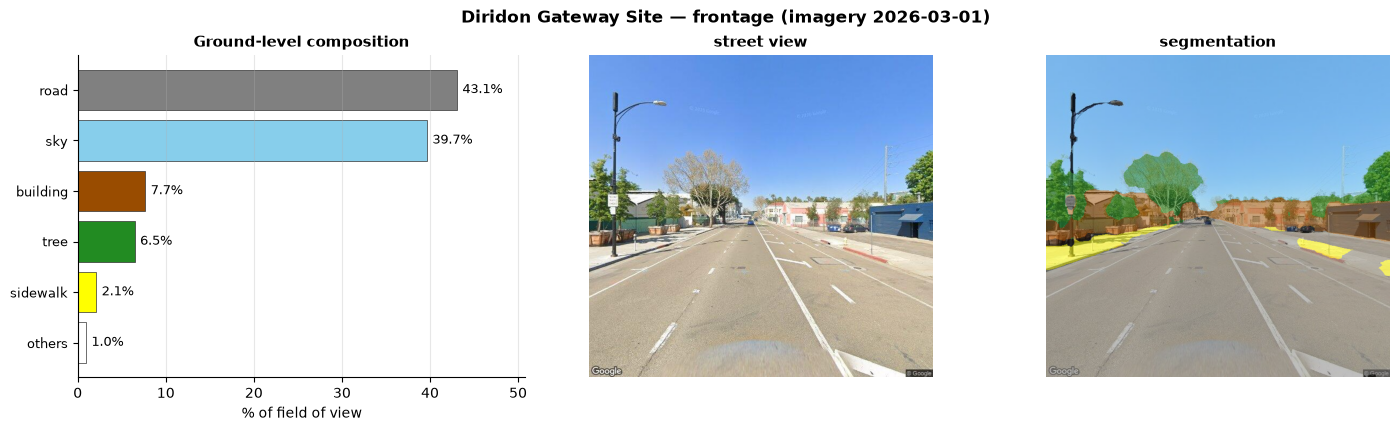

In [15]:
fig_sv = None
if SV_SEGMENTS:
    imgs = [(n, i) for n, i in (('street view', SV_IMGS.get('original')),
                                ('segmentation', SV_IMGS.get('segmented'))) if i is not None]
    fig, axes = plt.subplots(1, 1 + len(imgs), figsize=(4.8 * (1 + len(imgs)), 4.2),
                             constrained_layout=True)
    axes = np.atleast_1d(axes)
    items  = sorted(SV_SEGMENTS.items(), key=lambda kv: -kv[1])
    labels = [k for k, _ in items]
    vals   = [v for _, v in items]
    cols   = ['#%02x%02x%02x' % tuple(SV_LEGEND[k][:3])
              if k in SV_LEGEND and len(SV_LEGEND.get(k, [])) >= 3
              else '#8895a4' for k in labels]
    ypos = np.arange(len(labels))[::-1]
    axes[0].barh(ypos, vals, color=cols, edgecolor='#333', linewidth=0.5)
    for y, v in zip(ypos, vals):
        axes[0].text(v + 0.6, y, f'{v:.1f}%', va='center', fontsize=9)
    axes[0].set_yticks(ypos); axes[0].set_yticklabels(labels, fontsize=9)
    axes[0].set_xlabel('% of field of view')
    axes[0].set_xlim(0, max(vals) * 1.18)
    axes[0].set_title('Ground-level composition', fontsize=11, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    for sp in ('top', 'right'):
        axes[0].spines[sp].set_visible(False)
    for i, (name, img) in enumerate(imgs, start=1):
        axes[i].imshow(img); axes[i].axis('off')
        axes[i].set_title(name, fontsize=10.5, fontweight='bold')
    fig.suptitle(f'{PARCEL_NAME} — frontage'
                 + (f' (imagery {SV_DATE})' if SV_DATE else ''),
                 fontsize=12.5, fontweight='bold')
    fig_sv = fig
    plt.show()

## Step 8 — Comfort through the day

### What you are doing
Environmental parameters at the parcel centroid for `STUDY_DATE`, anchored to the
parcel's area-weighted peak from Step 4. Returns 24-hour series for heat index,
apparent temperature, wet-bulb, humidity, solar irradiance, and air quality.

### Why this matters
The endpoint needs a `temperature` anchor at the point to derive comfort metrics,
and Step 4 has already produced a defensible one for this parcel — so the curves
below are anchored to *this site*, not to a regional average.

### Read the heat-index curve correctly — it is not a diurnal forecast

This is the single easiest number in the whole API to misread, so it is worth
being precise about.

The endpoint applies your **single `temperature` anchor to all 24 hours** and
varies only humidity. Heat index is a function of temperature and humidity, so
`heat_index_celsius` ends up tracking relative humidity exactly — and because
humidity peaks overnight, **the heat-index curve peaks at around 2 a.m. and
bottoms out mid-afternoon.** You can verify it below: the argmax of heat index
and the argmax of relative humidity are the same hour, on this parcel and on
every cached sample in `data/env_params/`.

That curve is therefore a **humidity-sensitivity curve at a fixed temperature**,
not a diurnal profile. It is only physically meaningful at the hours when the
real air temperature is actually near the anchor — that is, around the afternoon
peak. At 2 a.m. the real air temperature here is about 16 °C, not the 27 °C
anchor, so the 32 °C night-time heat index describes conditions that do not
occur.

So the notebook takes the heat index **at the true hot hour** — the hour when
apparent temperature peaks — and uses that for every threshold comparison. It
deliberately does *not* count "hours above a threshold" from this series, because
most of those hours would be night-time artifacts. Duration comes from the
heatmap `exceedance` layer in Step 5, which is measured, not derived.

`apparent_temperature_celsius` does follow the real diurnal cycle and is plotted
alongside so the difference is visible.

In [16]:
ENV = cached_or_live(
    ENV_DIR / f'env_params_{SLUG}_{STUDY_DATE}.json',
    'environmental parameters', client.environmental_parameters if HAVE_API else None,
    latitude=CY, longitude=CX, temperature=float(PARCEL_PEAK),
    start_date=STUDY_DATE, start_time=STUDY_HOUR, filter_type=3,
)

meta       = (ENV or {}).get('metadata') or {}
loc        = ((ENV or {}).get('locations') or [{}])[0]
PARAMS     = loc.get('parameters') or {}
TIMESTAMPS = meta.get('timestamps') or []
TZ         = meta.get('timezone', '')
SOLAR      = loc.get('solar_irradiance') or {}

def series(name):
    v = PARAMS.get(name)
    return [x for x in v] if isinstance(v, list) else []

HI   = series('heat_index_celsius')
APP  = series('apparent_temperature_celsius')
WB   = series('wet_bulb_temperature_celsius')
RH   = series('relative_humidity_percent')

PEAK_APP = max((v for v in APP if v is not None), default=None)
PEAK_WB  = max((v for v in WB if v is not None), default=None)

# The true hot hour = where apparent temperature peaks. apparent_temperature
# follows the real diurnal cycle; heat index does not (see the note above).
HOT_HOUR = APP.index(PEAK_APP) if PEAK_APP is not None else None

# Heat index AT the hot hour — the only hour where the constant temperature anchor
# reflects reality, so the only value defensible against a published threshold.
HI_AT_PEAK = HI[HOT_HOUR] if (HI and HOT_HOUR is not None and HOT_HOUR < len(HI)) else None

# Retained for transparency, NOT used for any finding: the raw max of the
# heat-index series, which lands overnight and is a humidity artifact.
HI_RAW_MAX      = max((v for v in HI if v is not None), default=None)
HI_RAW_MAX_HOUR = HI.index(HI_RAW_MAX) if HI_RAW_MAX is not None else None
RH_MAX_HOUR     = RH.index(max(v for v in RH if v is not None)) if RH else None

print(f'timezone {TZ}   elevation {loc.get("elevation", "n/a")} m   '
      f'anchor {loc.get("temperature", "n/a"):.2f} °C')
print()
print(f'  hot hour (apparent temp peaks): {HOT_HOUR:02d}:00   '
      f'apparent temp {PEAK_APP:.1f} °C')
print(f'  heat index AT the hot hour    : {HI_AT_PEAK:.1f} °C   <- used for findings')
print(f'  peak wet-bulb                 : {PEAK_WB:.1f} °C')
print()
print(f'  [artifact check] heat-index series maxes at {HI_RAW_MAX:.1f} °C at '
      f'{HI_RAW_MAX_HOUR:02d}:00,')
print(f'                   relative humidity maxes at {RH_MAX_HOUR:02d}:00 -- '
      f'{"same hour, confirming the curve tracks humidity" if HI_RAW_MAX_HOUR == RH_MAX_HOUR else "different hours"}.')
print(f'                   That {HI_RAW_MAX:.1f} °C is NOT used: real air temperature at '
      f'{HI_RAW_MAX_HOUR:02d}:00 is near {PARCEL_MIN:.1f} °C, not the {PARCEL_PEAK:.1f} °C anchor.')

cached: environmental parameters <- data/env_params/env_params_parcel_diridon_san_jose_2024-07-15.json
timezone GMT-8   elevation 28.0 m   anchor 27.31 °C

  hot hour (apparent temp peaks): 13:00   apparent temp 24.9 °C
  heat index AT the hot hour    : 27.3 °C   <- used for findings
  peak wet-bulb                 : 17.1 °C

  [artifact check] heat-index series maxes at 32.5 °C at 02:00,
                   relative humidity maxes at 02:00 -- same hour, confirming the curve tracks humidity.
                   That 32.5 °C is NOT used: real air temperature at 02:00 is near 16.3 °C, not the 27.3 °C anchor.


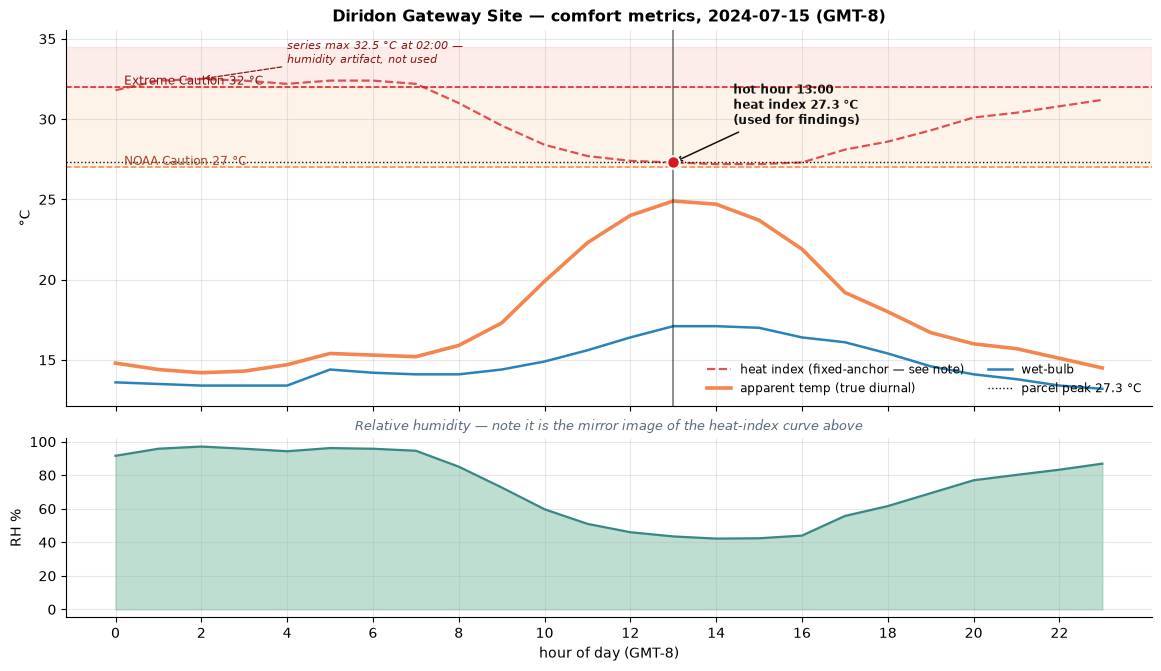

In [17]:
fig_env = None
if HI:
    hours = list(range(len(HI)))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 6.6), sharex=True,
                                   constrained_layout=True,
                                   gridspec_kw={'height_ratios': [2.1, 1]})

    ax1.axhspan(NOAA_EXTREME_C, max(NOAA_EXTREME_C + 1, (HI_RAW_MAX or 0) + 2),
                color='#e54f35', alpha=0.10)
    ax1.axhspan(NOAA_CAUTION_C, NOAA_EXTREME_C, color='#fdae61', alpha=0.14)
    ax1.axhline(NOAA_CAUTION_C, color='#f3854e', ls='--', lw=1.1)
    ax1.axhline(NOAA_EXTREME_C, color='#d7191c', ls='--', lw=1.1)
    ax1.text(0.2, NOAA_CAUTION_C + 0.15, f'NOAA Caution {NOAA_CAUTION_C:g} °C',
             fontsize=8.5, color='#a4442a')
    ax1.text(0.2, NOAA_EXTREME_C + 0.15, f'Extreme Caution {NOAA_EXTREME_C:g} °C',
             fontsize=8.5, color='#8c1512')

    # Heat index is dashed and de-emphasised: it is a humidity-sensitivity curve at
    # a fixed temperature anchor, valid only near the hot hour (marked).
    ax1.plot(hours, HI, lw=1.6, color='#d7191c', ls='--', alpha=0.75,
             label='heat index (fixed-anchor — see note)')
    if APP:
        ax1.plot(hours, APP, lw=2.6, color='#f3854e',
                 label='apparent temp (true diurnal)')
    if WB:
        ax1.plot(hours, WB, lw=1.8, color='#2983ba', label='wet-bulb')
    ax1.axhline(PARCEL_PEAK, color='#111', lw=1.0, ls=':',
                label=f'parcel peak {PARCEL_PEAK:.1f} °C')

    if HOT_HOUR is not None:
        ax1.axvline(HOT_HOUR, color='#111', lw=1.2, alpha=0.55)
        ax1.plot([HOT_HOUR], [HI_AT_PEAK], 'o', ms=9, color='#d7191c',
                 markeredgecolor='#fff', markeredgewidth=1.5, zorder=8)
        ax1.annotate(f'hot hour {HOT_HOUR:02d}:00\nheat index {HI_AT_PEAK:.1f} °C\n(used for findings)',
                     xy=(HOT_HOUR, HI_AT_PEAK), xytext=(HOT_HOUR + 1.4, HI_AT_PEAK + 2.4),
                     fontsize=8.5, fontweight='bold', color='#111',
                     arrowprops=dict(arrowstyle='->', color='#111', lw=1.1))
    if HI_RAW_MAX_HOUR is not None:
        ax1.annotate(f'series max {HI_RAW_MAX:.1f} °C at {HI_RAW_MAX_HOUR:02d}:00 —\n'
                     f'humidity artifact, not used',
                     xy=(HI_RAW_MAX_HOUR, HI_RAW_MAX),
                     xytext=(HI_RAW_MAX_HOUR + 2.0, HI_RAW_MAX + 1.0),
                     fontsize=8, style='italic', color='#8c1512',
                     arrowprops=dict(arrowstyle='->', color='#8c1512',
                                     lw=0.9, ls='--'))

    ax1.set_ylabel('°C')
    ax1.set_title(f'{PARCEL_NAME} — comfort metrics, {STUDY_DATE} ({TZ})',
                  fontsize=11.5, fontweight='bold')
    ax1.legend(fontsize=8.5, ncol=2, loc='lower right', frameon=False)
    ax1.grid(alpha=0.3)
    for sp in ('top', 'right'):
        ax1.spines[sp].set_visible(False)

    if RH:
        ax2.fill_between(hours, RH, color='#88c4aa', alpha=0.55)
        ax2.plot(hours, RH, lw=1.6, color='#3b8686')
        ax2.set_ylabel('RH %')
        ax2.set_title('Relative humidity — note it is the mirror image of the '
                      'heat-index curve above', fontsize=9.5, style='italic',
                      color='#5a6b7b')
    ax2.set_xlabel(f'hour of day ({TZ})')
    ax2.set_xticks(range(0, len(HI), 2))
    ax2.grid(alpha=0.3)
    for sp in ('top', 'right'):
        ax2.spines[sp].set_visible(False)

    fig_env = fig
    plt.show()

## Step 9 — Heat-intelligence narrative

### What you are doing
Requesting the heat-intelligence PDF for the parcel centroid and saving it into
the output bundle.

> **Plan limit:** the endpoint accepts up to **2 analysis categories per request**
> on the Premium plan — asking for all five returns
> `400: analysis types exceed current model limit of 2 types`. `HEAT_INTEL_ANALYSES`
> below picks the two that matter most for a development site; change them, or
> issue a second call, if you need the others.

### Why this matters
This is the one endpoint that returns prose rather than numbers. It ships to the
client alongside the quantitative report as the "why this site, in context"
narrative — geographic setting, environmental drivers, urban form, events, and
anthropogenic load. It is a companion document, not a substitute for the measured
sections above.

In [18]:
# Max 2 per request on Premium. 'urban' explains built form, 'environmental'
# explains the drivers — the pair a development site cares about.
HEAT_INTEL_ANALYSES = ('environmental', 'urban')

HEAT_INTEL_PDF = OUTPUTS_ROOT / f'heat_intelligence_{SLUG}_{STUDY_DATE}.pdf'
HEAT_INTEL_OK  = False

if HEAT_INTEL_PDF.exists() and not REFRESH:
    HEAT_INTEL_OK = True
    print(f'cached: heat-intelligence <- {HEAT_INTEL_PDF.relative_to(ROOT)}')
elif HAVE_API:
    try:
        # heat_intelligence downloads the PDF itself — it does not use the
        # submit/wait helper, so it is called directly.
        client.heat_intelligence(
            latitude=CY, longitude=CX, temperature=float(PARCEL_PEAK),
            date=STUDY_DATE, analysis=HEAT_INTEL_ANALYSES,
            output_path=HEAT_INTEL_PDF, timeout=900, verbose=True,
        )
        HEAT_INTEL_OK = HEAT_INTEL_PDF.exists()
    except Exception as exc:
        print(f'  heat-intelligence unavailable, continuing without it: {exc}')
else:
    print('No API key and no cached PDF — skipping the narrative report.')

if HEAT_INTEL_OK:
    print(f'  {HEAT_INTEL_PDF.relative_to(ROOT)}  '
          f'({HEAT_INTEL_PDF.stat().st_size / 1024:.0f} KB)')

cached: heat-intelligence <- outputs/parcel_diridon_san_jose_2024-07-15/heat_intelligence_parcel_diridon_san_jose_2024-07-15.pdf
  outputs/parcel_diridon_san_jose_2024-07-15/heat_intelligence_parcel_diridon_san_jose_2024-07-15.pdf  (687 KB)


## Step 10 — Findings and threshold-triggered recommendations

### What you are doing
Turning the measurements into a findings table. Every row is
*if measurement X crosses published threshold Y, recommend program Z* — the same
declarative pattern the public-parks notebook uses.

### Why this matters
No invented composite index and no fabricated dollar figures. Each threshold is
one somebody else published — NOAA, OSHA, EPA, USDA, ASHRAE — so a finding can be
traced to its source in a diligence memo and defended in front of a lender or a
planning commission. A score of "7.4/10" cannot be.

In [19]:
FINDINGS = []

def finding(trigger, measured, threshold, verdict, action, program):
    FINDINGS.append({
        'trigger': trigger, 'measured': measured, 'threshold': threshold,
        'verdict': verdict, 'action': action, 'program': program,
    })

# --- exposure magnitude -----------------------------------------------------
if CITY_PCT is not None:
    hot = CITY_PCT >= 66
    finding('Parcel daily peak vs. city',
            f'{PARCEL_PEAK:.2f} °C ({CITY_PCT:.0f}th pct)',
            'citywide median',
            'ABOVE' if hot else 'AT OR BELOW',
            ('Size cooling plant to the upper-tercile case; do not use a citywide '
             'average in the energy model.') if hot else
            'Standard design assumptions are defensible for the snapshot.',
            'ASHRAE 90.1 — Energy Standard for Buildings')

# --- exposure duration (the primary metric at this scale) -------------------
exc_share = 100.0 * EXC['parcel'] / WINDOW_HOURS
finding(f'Hours above {NOAA_CAUTION_C:g} °C over {WINDOW_HOURS} h',
        f'{EXC["parcel"]:.1f} h ({exc_share:.0f}% of window)',
        f'{NOAA_CAUTION_C:g} °C (NOAA Caution)',
        'ELEVATED' if exc_share >= 20 else 'MODERATE',
        ('Cooling load is duration-driven, not peak-driven; model annual hours, '
         'and specify envelope for sustained rather than instantaneous load.')
        if exc_share >= 20 else
        'Peak-based sizing is adequate; duration is not the binding constraint.',
        'ASHRAE 90.1 / ASHRAE 55 — Thermal Environmental Conditions')

finding('Longest consecutive run above threshold',
        f'{PER["parcel"]:.1f} h',
        '12 h (overnight recovery)',
        'NO OVERNIGHT RECOVERY' if PER['parcel'] >= 12 else 'RECOVERS OVERNIGHT',
        ('Thermal mass will not shed absorbed heat overnight — favour reflective '
         'envelope and night-flush ventilation over exposed mass.')
        if PER['parcel'] >= 12 else
        'Exposed thermal mass remains a viable passive strategy on this site.',
        'EPA Heat Island Reduction — Cool Roofs')

# --- surface composition ----------------------------------------------------
if SEGMENTS:
    if IMPERVIOUS_PCT > IMPERVIOUS_LIMIT:
        finding('Impervious surface share (site vicinity)',
                f'{IMPERVIOUS_PCT:.1f}%', f'{IMPERVIOUS_LIMIT:g}%',
                'EXCEEDS',
                'Specify high-albedo roofing and cool or permeable paving at design stage.',
                'EPA Heat Island Reduction — Cool Roofs & Cool Pavements')
    else:
        finding('Impervious surface share (site vicinity)',
                f'{IMPERVIOUS_PCT:.1f}%', f'{IMPERVIOUS_LIMIT:g}%', 'WITHIN',
                'No cool-surface retrofit indicated by surface share alone.',
                'EPA Heat Island Reduction')

    if CANOPY_PCT < CANOPY_TARGET:
        finding('Tree canopy share (site vicinity)',
                f'{CANOPY_PCT:.1f}%', f'{CANOPY_TARGET:g}%',
                'BELOW',
                'Include a planting plan in the landscape package; quantify the '
                'canopy benefit before entitlement hearings.',
                'USDA Forest Service — i-Tree')
    else:
        finding('Tree canopy share (site vicinity)',
                f'{CANOPY_PCT:.1f}%', f'{CANOPY_TARGET:g}%', 'MEETS',
                'Existing canopy is an asset — protect it through construction.',
                'USDA Forest Service — i-Tree')

# --- ground level -----------------------------------------------------------
if SV_SEGMENTS:
    finding('Ground-level vegetation at frontage',
            f'{SV_VEG:.1f}% of field of view', '10% (pedestrian shade)',
            'BELOW' if SV_VEG < 10 else 'ADEQUATE',
            ('Frontage reads as unshaded at eye level — street trees or a shade '
             'structure are needed for any ground-floor active use.')
            if SV_VEG < 10 else
            'Frontage already offers usable pedestrian shade.',
            'NACTO Urban Street Design Guide')

# --- comfort and worker safety ---------------------------------------------
if HI_AT_PEAK is not None:
    finding(f'Heat index at the hot hour ({HOT_HOUR:02d}:00)',
            f'{HI_AT_PEAK:.1f} °C', f'{NOAA_EXTREME_C:g} °C (Extreme Caution)',
            'EXCEEDS' if HI_AT_PEAK >= NOAA_EXTREME_C else
            ('CAUTION BAND' if HI_AT_PEAK >= NOAA_CAUTION_C else 'BELOW'),
            ('Occupant-comfort risk at peak; specify to ASHRAE 55 and plan shaded '
             'outdoor amenity.') if HI_AT_PEAK >= NOAA_EXTREME_C else
            ('Peak-hour heat index sits in the NOAA Caution band — tolerable, but '
             'shaded outdoor amenity is still indicated for sustained use.')
            if HI_AT_PEAK >= NOAA_CAUTION_C else
            'Peak-hour heat index stays below the NOAA Caution onset.',
            'ASHRAE 55 — Thermal Environmental Conditions')

    # Worker-safety is judged at the hot hour only. Counting hours from the
    # heat-index series would count overnight humidity artifacts as daytime
    # exposure — see the note in Step 8. Measured duration comes from Step 5.
    finding('Construction-phase worker exposure at peak hour',
            f'{HI_AT_PEAK:.1f} °C at {HOT_HOUR:02d}:00',
            f'{OSHA_HIGH_C:g} °C (OSHA high-heat)',
            'TRIGGERED' if HI_AT_PEAK >= OSHA_HIGH_C else 'NOT TRIGGERED',
            ('Build a heat-illness prevention plan into the construction schedule '
             'and bid documents — mandatory rest, shade, and water provisions.')
            if HI_AT_PEAK >= OSHA_HIGH_C else
            (f'Not triggered on this study day. The site does spend '
             f'{EXC["parcel"]:.0f} h above {NOAA_CAUTION_C:g} °C air temperature per '
             f'{WINDOW_HOURS} h (Step 5), so re-check against a summer design day '
             'before ruling it out for the build window.'),
            'OSHA Heat Illness Prevention')

if PEAK_WB is not None:
    finding('Peak wet-bulb temperature',
            f'{PEAK_WB:.1f} °C', '26 °C (evaporative-cooling limit)',
            'ABOVE' if PEAK_WB >= 26 else 'BELOW',
            ('Evaporative cooling loses effectiveness — plan for mechanical '
             'refrigeration.') if PEAK_WB >= 26 else
            'Evaporative and hybrid cooling strategies remain viable on this site.',
            'ASHRAE Handbook — HVAC Applications')

findings_df = pd.DataFrame(FINDINGS)
display(findings_df[['trigger', 'measured', 'threshold', 'verdict']])
print()
for f in FINDINGS:
    print(f'[{f["verdict"]}] {f["trigger"]}: {f["measured"]} (vs {f["threshold"]})')
    print(f'    -> {f["action"]}')
    print(f'       Program: {f["program"]}')

,trigger,measured,threshold,verdict
0,Parcel daily peak vs. city,27.31 °C (47th pct),citywide median,AT OR BELOW
1,Hours above 27 °C over 168 h,35.6 h (21% of window),27 °C (NOAA Caution),ELEVATED
2,Longest consecutive run above threshold,6.5 h,12 h (overnight recovery),RECOVERS OVERNIGHT
3,Impervious surface share (site vicinity),26.9%,60%,WITHIN
4,Tree canopy share (site vicinity),1.6%,15%,BELOW
5,Ground-level vegetation at frontage,6.5% of field of view,10% (pedestrian shade),BELOW
6,Heat index at the hot hour (13:00),27.3 °C,32 °C (Extreme Caution),CAUTION BAND
7,Construction-phase worker exposure at peak hour,27.3 °C at 13:00,32.2 °C (OSHA high-heat),NOT TRIGGERED
8,Peak wet-bulb temperature,17.1 °C,26 °C (evaporative-cooling limit),BELOW



[AT OR BELOW] Parcel daily peak vs. city: 27.31 °C (47th pct) (vs citywide median)
    -> Standard design assumptions are defensible for the snapshot.
       Program: ASHRAE 90.1 — Energy Standard for Buildings
[ELEVATED] Hours above 27 °C over 168 h: 35.6 h (21% of window) (vs 27 °C (NOAA Caution))
    -> Cooling load is duration-driven, not peak-driven; model annual hours, and specify envelope for sustained rather than instantaneous load.
       Program: ASHRAE 90.1 / ASHRAE 55 — Thermal Environmental Conditions
[RECOVERS OVERNIGHT] Longest consecutive run above threshold: 6.5 h (vs 12 h (overnight recovery))
    -> Exposed thermal mass remains a viable passive strategy on this site.
       Program: EPA Heat Island Reduction — Cool Roofs
[WITHIN] Impervious surface share (site vicinity): 26.9% (vs 60%)
    -> No cool-surface retrofit indicated by surface share alone.
       Program: EPA Heat Island Reduction
[BELOW] Tree canopy share (site vicinity): 1.6% (vs 15%)
    -> Include a p

## Step 11 — `reportAll`: assemble the client deliverable

### What you are doing
Packaging every layer into one bundle: a branded PDF, a flat CSV of every measured
value, standalone HTML maps, and the heat-intelligence narrative alongside.

### Why this matters
This is the point of the notebook. A developer's diligence file needs one
document that answers "what is the thermal exposure of this site" with the
measurements, the methods, and the sources attached — not six screenshots from
six endpoints. The CSV exists so the numbers can go straight into a pro-forma or
an energy model; the PDF exists so the same numbers survive the trip to a lender.

In [20]:
import io, base64
from PIL import Image as PILImage

from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle,
    PageBreak, KeepTogether,
)

OUT_DIR = OUTPUTS_ROOT
(OUT_DIR / 'maps').mkdir(parents=True, exist_ok=True)

# ── 1. flat CSV of every measured value ────────────────────────────────────
record = {
    'parcel_id': PARCEL_ID, 'name': PARCEL_NAME,
    'address': ATTRS.get('address'), 'city': ATTRS.get('city'),
    'state': ATTRS.get('state'), 'zoning': ATTRS.get('zoning'),
    'proposed_use': ATTRS.get('proposed_use'), 'proposed_gsf': ATTRS.get('proposed_gsf'),
    'centroid_lat': round(CY, 6), 'centroid_lon': round(CX, 6),
    'lot_area_m2': round(AREA_M2, 1), 'lot_area_acres': round(AREA_ACRES, 3),
    'extent_x_m': round(EXTENT_X, 1), 'extent_y_m': round(EXTENT_Y, 1),
    'study_date': STUDY_DATE, 'granularity_m': GRANULARITY_M,
    'aoi_buffer_m': BUFFER_M, 'aoi_km2': round(AOI_KM2, 4), 'aoi_tiles': len(tiles),
    'parcel_tiles_overlapped': len(peak_parts),
    'parcel_peak_c': None if PARCEL_PEAK is None else round(PARCEL_PEAK, 3),
    'parcel_mean_c': None if PARCEL_MEAN is None else round(PARCEL_MEAN, 3),
    'parcel_min_c': None if PARCEL_MIN is None else round(PARCEL_MIN, 3),
    'diurnal_swing_c': None if PARCEL_SWING is None else round(PARCEL_SWING, 3),
    'aoi_percentile': round(AOI_PCT, 1),
    'city_percentile': None if CITY_PCT is None else round(CITY_PCT, 1),
    'city_delta_c': None if CITY_DELTA is None else round(CITY_DELTA, 3),
    'window_start': WINDOW_START, 'window_end': WINDOW_END,
    'window_hours': WINDOW_HOURS, 'exceedance_threshold_c': NOAA_CAUTION_C,
    'exceedance_hours': None if EXC['parcel'] is None else round(EXC['parcel'], 2),
    'exceedance_share_pct': None if EXC['parcel'] is None
                            else round(100 * EXC['parcel'] / WINDOW_HOURS, 1),
    'persistence_hours': None if PER['parcel'] is None else round(PER['parcel'], 2),
    'impervious_pct': round(IMPERVIOUS_PCT, 2) if SEGMENTS else None,
    'canopy_pct': round(CANOPY_PCT, 2) if SEGMENTS else None,
    'vegetation_pct': round(VEG_PCT, 2) if SEGMENTS else None,
    'streetview_vegetation_pct': round(SV_VEG, 2) if SV_SEGMENTS else None,
    'streetview_sky_pct': round(SV_SKY, 2) if SV_SEGMENTS else None,
    'streetview_imagery_date': SV_DATE,
    'hot_hour': HOT_HOUR,
    'heat_index_at_hot_hour_c': None if HI_AT_PEAK is None else round(HI_AT_PEAK, 2),
    'peak_apparent_temp_c': None if PEAK_APP is None else round(PEAK_APP, 2),
    'peak_wet_bulb_c': None if PEAK_WB is None else round(PEAK_WB, 2),
    # Reported for transparency only — the raw series max is an overnight humidity
    # artifact of the fixed temperature anchor and drives no finding. See Step 8.
    'heat_index_series_max_c': None if HI_RAW_MAX is None else round(HI_RAW_MAX, 2),
    'heat_index_series_max_hour': HI_RAW_MAX_HOUR,
}
parcel_csv = OUT_DIR / 'parcel_evaluation.csv'
pd.DataFrame([record]).to_csv(parcel_csv, index=False)
print(f'  {parcel_csv.relative_to(ROOT)}')

findings_csv = OUT_DIR / 'findings.csv'
findings_df.to_csv(findings_csv, index=False)
print(f'  {findings_csv.relative_to(ROOT)}')

# ── 2. standalone maps ─────────────────────────────────────────────────────
m_context.save(str(OUT_DIR / 'maps' / 'parcel_context.html'))
print('  maps/parcel_context.html')

m_heat = folium.Map(location=[CY, CX], zoom_start=15, tiles='CartoDB positron')
_pk = [t[2] for t in tiles if t[2] is not None]
_lo, _hi = min(_pk), max(_pk)
for poly, _mean, peak, _mn in tiles:
    if peak is None:
        continue
    folium.Polygon(
        [(y, x) for x, y in poly.exterior.coords],
        color=None, fill=True, fill_color=temp_color(peak, _lo, _hi),
        fill_opacity=0.65, weight=0, tooltip=f'{peak:.2f} °C',
    ).add_to(m_heat)
folium.GeoJson(mapping(PARCEL), name='Parcel',
               style_function=lambda _: {'color': '#111', 'weight': 3,
                                         'fillOpacity': 0.0}).add_to(m_heat)
m_heat.save(str(OUT_DIR / 'maps' / 'parcel_heat_layer.html'))
print('  maps/parcel_heat_layer.html')

# ── 3. PDF ─────────────────────────────────────────────────────────────────
PAGE_W, PAGE_H = letter
LEFT_MARGIN = RIGHT_MARGIN = 0.6 * inch
TOP_MARGIN  = BOT_MARGIN   = 0.7 * inch
USABLE_W    = PAGE_W - LEFT_MARGIN - RIGHT_MARGIN

BRAND_BLUE   = colors.HexColor('#0E4A8A')
BRAND_INK    = colors.HexColor('#1f2933')
BRAND_MUTED  = colors.HexColor('#5a6b7b')
BRAND_YELLOW = colors.HexColor('#FFD24D')

LOGO_PATH        = ROOT / 'assets' / 'fortyguard_logo.png'
LOGO_FOOTER_PATH = ROOT / 'assets' / 'fortyguard_logo_footer.png'
COVER_BG_PATH    = ROOT / 'assets' / 'cover_bg.png'
LOGO_ASPECT, LOGO_FOOTER_ASPECT = 224 / 1208, 68 / 364

REPORT_NAME = 'Single-Parcel Heat Due Diligence'

_styles = getSampleStyleSheet()
S_H1   = ParagraphStyle('H1', parent=_styles['Heading1'], fontName='Helvetica-Bold',
                        fontSize=16, leading=20, textColor=BRAND_BLUE,
                        spaceBefore=4, spaceAfter=10)
S_H2   = ParagraphStyle('H2', parent=_styles['Heading2'], fontName='Helvetica-Bold',
                        fontSize=12, leading=15, textColor=BRAND_INK,
                        spaceBefore=4, spaceAfter=6)
S_BODY = ParagraphStyle('Body', parent=_styles['BodyText'], fontName='Helvetica',
                        fontSize=10, leading=14, textColor=BRAND_INK, spaceAfter=4)
S_SM   = ParagraphStyle('Sm', parent=S_BODY, fontSize=8, leading=11)
S_CAP  = ParagraphStyle('Cap', parent=_styles['Italic'], fontName='Helvetica-Oblique',
                        fontSize=9, leading=12, textColor=BRAND_MUTED, spaceAfter=8)

def _h1(t): return Paragraph(str(t).upper().replace('&', '&amp;'), S_H1)
def _h2(t): return Paragraph(str(t).upper().replace('&', '&amp;'), S_H2)
def _p(t, s=S_BODY): return Paragraph(str(t).replace('&', '&amp;'), s)

def _fig(fig, width_in=6.9, dpi=170):
    if fig is None:
        return None
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')
    buf.seek(0)
    iw, ih = PILImage.open(buf).size
    return RLImage(buf, width=width_in * inch, height=width_in * inch * ih / iw)

TABLE_STYLE = TableStyle([
    ('BACKGROUND',     (0, 0), (-1, 0),  BRAND_BLUE),
    ('TEXTCOLOR',      (0, 0), (-1, 0),  colors.white),
    ('FONTNAME',       (0, 0), (-1, 0),  'Helvetica-Bold'),
    ('FONTSIZE',       (0, 0), (-1, 0),  9),
    ('VALIGN',         (0, 0), (-1, -1), 'MIDDLE'),
    ('FONTSIZE',       (0, 1), (-1, -1), 8),
    ('LEFTPADDING',    (0, 0), (-1, -1), 6),
    ('RIGHTPADDING',   (0, 0), (-1, -1), 6),
    ('TOPPADDING',     (0, 0), (-1, -1), 5),
    ('BOTTOMPADDING',  (0, 0), (-1, -1), 5),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#f4f7fb')]),
    ('LINEBELOW',      (0, -1), (-1, -1), 0.4, colors.HexColor('#cbd5e0')),
])


def _draw_cover(canvas, doc):
    canvas.saveState()
    if COVER_BG_PATH.exists():
        canvas.drawImage(str(COVER_BG_PATH), 0, 0, width=PAGE_W, height=PAGE_H,
                         preserveAspectRatio=False, mask='auto')
    else:
        canvas.setFillColor(BRAND_BLUE)
        canvas.rect(0, 0, PAGE_W, PAGE_H, stroke=0, fill=1)

    pill_w, pill_h = 1.45 * inch, 0.34 * inch
    pill_y = PAGE_H - 1.05 * inch
    canvas.setFillColor(BRAND_YELLOW)
    canvas.roundRect(LEFT_MARGIN, pill_y, pill_w, pill_h, pill_h / 2, stroke=0, fill=1)
    canvas.setFillColor(BRAND_INK)
    canvas.setFont('Helvetica-Bold', 11)
    canvas.drawCentredString(LEFT_MARGIN + pill_w / 2, pill_y + pill_h / 2 - 0.04 * inch,
                             STUDY_DATE)

    canvas.setFillColor(colors.white)
    canvas.setFont('Helvetica-Bold', 38)
    top_y, line_h = PAGE_H - 1.8 * inch, 0.55 * inch
    for i, line in enumerate(('SINGLE-PARCEL', 'HEAT DUE', 'DILIGENCE')):
        canvas.drawString(LEFT_MARGIN, top_y - i * line_h, line)

    def _info(y, label, value):
        canvas.setFont('Helvetica-Bold', 11); canvas.setFillColor(BRAND_YELLOW)
        canvas.drawString(LEFT_MARGIN, y, label)
        w = canvas.stringWidth(label, 'Helvetica-Bold', 11)
        canvas.setFont('Helvetica', 11); canvas.setFillColor(colors.white)
        canvas.drawString(LEFT_MARGIN + w + 0.06 * inch, y, value)

    y = top_y - 2 * line_h - 0.55 * inch
    _info(y, 'Site:', f' {PARCEL_NAME}  ({PARCEL_ID})')
    _info(y - 0.28 * inch, 'Lot:',
          f' {AREA_ACRES:.2f} acres  ·  {EXTENT_X:.0f} x {EXTENT_Y:.0f} m')
    _info(y - 0.56 * inch, 'AOI:',
          f' {AOI_KM2:.2f} km2  ·  {len(tiles):,} tiles at {GRANULARITY_M} m')
    _info(y - 0.84 * inch, 'Parcel peak:',
          f' {PARCEL_PEAK:.2f} °C'
          + (f'  ({CITY_PCT:.0f}th pct citywide)' if CITY_PCT is not None else ''))

    for i in range(3):
        canvas.setFillColor(BRAND_YELLOW)
        canvas.circle(LEFT_MARGIN + 0.10 * inch + i * 0.32 * inch,
                      y - 1.26 * inch, 0.10 * inch, stroke=0, fill=1)

    logo_w = 3.6 * inch
    if LOGO_PATH.exists():
        canvas.drawImage(str(LOGO_PATH), LEFT_MARGIN, 1.2 * inch,
                         width=logo_w, height=logo_w * LOGO_ASPECT, mask='auto')
    canvas.restoreState()


def _draw_body(canvas, doc):
    canvas.saveState()
    canvas.setStrokeColor(colors.HexColor('#cbd5e0')); canvas.setLineWidth(0.4)
    canvas.line(LEFT_MARGIN, 0.6 * inch, PAGE_W - RIGHT_MARGIN, 0.6 * inch)
    if LOGO_FOOTER_PATH.exists():
        fw = 0.85 * inch
        canvas.drawImage(str(LOGO_FOOTER_PATH), LEFT_MARGIN, 0.32 * inch,
                         width=fw, height=fw * LOGO_FOOTER_ASPECT, mask='auto')
    canvas.setFont('Helvetica', 8); canvas.setFillColor(BRAND_MUTED)
    canvas.drawString(LEFT_MARGIN + 1.0 * inch, 0.4 * inch,
                      f'{REPORT_NAME}  ·  {PARCEL_NAME}  ·  {STUDY_DATE}')
    canvas.drawRightString(PAGE_W - RIGHT_MARGIN, 0.4 * inch, f'Page {doc.page}')
    canvas.restoreState()


# ── flowables ──────────────────────────────────────────────────────────────
F = [PageBreak()]

F += [_h1('Executive summary'),
      _p(f'<b>{PARCEL_NAME}</b> ({PARCEL_ID}) — {ATTRS.get("address", "")}, '
         f'{ATTRS.get("city", "")} {ATTRS.get("state", "")}. '
         f'{AREA_ACRES:.2f}-acre parcel, zoning {ATTRS.get("zoning", "n/a")}, '
         f'proposed use {ATTRS.get("proposed_use", "n/a")}.'),
      Spacer(1, 0.12 * inch)]

_summary_rows = [
    ['Metric', 'Value', 'Reference'],
    ['Parcel daily peak (area-weighted)', f'{PARCEL_PEAK:.2f} °C',
     (f'{CITY_PCT:.0f}th pct citywide' if CITY_PCT is not None else 'no city baseline')],
    ['Parcel daily mean', f'{PARCEL_MEAN:.2f} °C', f'AOI mean {np.mean(aoi_means):.2f} °C'],
    ['Diurnal swing', f'{PARCEL_SWING:.2f} °C', 'peak minus daily minimum'],
    [f'Hours above {NOAA_CAUTION_C:g} °C', f'{EXC["parcel"]:.1f} h of {WINDOW_HOURS} h',
     f'{100 * EXC["parcel"] / WINDOW_HOURS:.0f}% of window'],
    ['Longest consecutive run', f'{PER["parcel"]:.1f} h', 'overnight recovery at <12 h'],
]
if SEGMENTS:
    _summary_rows += [
        ['Impervious share (vicinity)', f'{IMPERVIOUS_PCT:.1f}%',
         f'EPA trigger >{IMPERVIOUS_LIMIT:g}%'],
        ['Tree canopy (vicinity)', f'{CANOPY_PCT:.1f}%',
         f'USDA trigger <{CANOPY_TARGET:g}%'],
    ]
if HI_AT_PEAK is not None:
    _summary_rows += [
        [f'Heat index at hot hour ({HOT_HOUR:02d}:00)', f'{HI_AT_PEAK:.1f} °C',
         f'NOAA Extreme Caution {NOAA_EXTREME_C:g} °C'],
        ['Peak apparent temperature', f'{PEAK_APP:.1f} °C', f'at {HOT_HOUR:02d}:00'],
        ['Peak wet-bulb', f'{PEAK_WB:.1f} °C', 'evaporative limit 26 °C'],
    ]
_t = Table(_summary_rows, colWidths=[2.6 * inch, 1.9 * inch, 2.4 * inch],
           repeatRows=1, hAlign='LEFT')
_t.setStyle(TABLE_STYLE)
F += [_t, Spacer(1, 0.2 * inch)]

F += [_p('<b>Method.</b> A single heatmap was run over the parcel plus a '
         f'{BUFFER_M} m context ring ({AOI_KM2:.2f} km², {len(tiles):,} tiles at '
         f'{GRANULARITY_M} m). Parcel figures are the <b>area-weighted mean</b> of '
         f'the {len(peak_parts)} tiles the boundary overlaps, weighted by overlap '
         'area — not a centroid lookup. At 60 m the parcel spans roughly '
         f'{AREA_M2 / GRANULARITY_M ** 2:.1f} tiles, so a nearest-tile reading would '
         'discard most of the site.', S_SM),
      _p('<b>Why duration leads.</b> Across this AOI the daily-peak snapshot varies '
         f'by only {max(aoi_peaks) - min(aoi_peaks):.2f} °C, while hours-above-threshold '
         f'varies by {max(exc_vals) - min(exc_vals):.1f} h. At parcel scale the '
         'duration layers, not the snapshot, carry the signal.', S_SM),
      PageBreak()]

# findings
F += [_h1('Findings and recommended actions'),
      _p('Each row is a published threshold, the measured value against it, and the '
         'program the action comes from. No composite index is used.', S_CAP)]
_frows = [['Trigger', 'Measured', 'Threshold', 'Verdict']]
for f_ in FINDINGS:
    _frows.append([Paragraph(f_['trigger'], S_SM), Paragraph(f_['measured'], S_SM),
                   Paragraph(f_['threshold'], S_SM), Paragraph(f_['verdict'], S_SM)])
_ft = Table(_frows, colWidths=[2.3 * inch, 1.7 * inch, 1.7 * inch, 1.2 * inch],
            repeatRows=1, hAlign='LEFT')
_ft.setStyle(TABLE_STYLE)
F += [_ft, Spacer(1, 0.18 * inch)]
for f_ in FINDINGS:
    F += [_p(f'<b>{f_["trigger"]}</b> — {f_["verdict"]}', S_BODY),
          _p(f_['action'], S_SM),
          _p(f'<i>Program: {f_["program"]}</i>', S_CAP)]
F += [PageBreak()]

# figures
for title, fig_obj, caption in (
    ('Site context and heat layer', globals().get('fig_clip'),
     'Area-weighted clip: every tile the boundary overlaps, with its share of the lot.'),
    ('Exposure duration', globals().get('fig_duration'),
     f'Hours above {NOAA_CAUTION_C:g} °C and longest consecutive run, '
     f'{WINDOW_START} to {WINDOW_END}.'),
    ('Surface composition', globals().get('fig_sat'),
     'Satellite land-cover segmentation at the site vicinity.'),
    ('Frontage', globals().get('fig_sv'),
     'Street-view segmentation — the vertical environment at ground level.'),
    ('Comfort metrics', globals().get('fig_env'),
     'Apparent temperature follows the true diurnal cycle. The heat-index curve '
     '(dashed) is derived from a fixed temperature anchor and varies only with '
     'humidity, so it inverts — only its value at the hot hour is used.'),
):
    img = _fig(fig_obj)
    if img is None:
        continue
    F += [_h2(title), img, _p(caption, S_CAP), Spacer(1, 0.15 * inch)]

F += [PageBreak(), _h1('Sources and limits'),
      _p('<b>Thresholds.</b> NOAA heat-index Caution (27 °C) and Extreme Caution '
         '(32 °C); OSHA high-heat trigger (32.2 °C); EPA Heat Island Reduction '
         'cool-roof / cool-pavement guidance; USDA Forest Service i-Tree canopy '
         'targets; ASHRAE 90.1 and ASHRAE 55.', S_SM),
      _p(f'<b>Data.</b> FortyGuard tOS Enterprise API. Heatmap {STUDY_DATE} at '
         f'{GRANULARITY_M} m; exposure duration {WINDOW_START} to {WINDOW_END}; '
         'satellite, street-view, and environmental parameters at the parcel '
         'centroid.', S_SM),
      _p('<b>Limits.</b> Satellite and street-view segmentation are anchored to the '
         'parcel centroid and describe the site vicinity, not the parcel polygon '
         'exactly. The heatmap resolves to 60 m, coarser than the parcel, so '
         'within-site variation is not resolved. Comfort metrics derive from a '
         'single study day and should be re-run against a summer design day before '
         'they inform final mechanical sizing.', S_SM),
      _p('<b>Heat index.</b> The environmental-parameters endpoint applies one '
         'temperature anchor across all 24 hours and varies only humidity, so the '
         'heat-index series tracks humidity and peaks overnight — an artifact, not '
         'a forecast. This report uses heat index only at the hot hour '
         + (f'({HOT_HOUR:02d}:00, {HI_AT_PEAK:.1f} °C), ' if HI_AT_PEAK is not None else '')
         + 'where the anchor reflects real conditions. All duration figures come '
         'from the measured heatmap exceedance layer, not from this series.', S_SM)]

report_pdf = OUT_DIR / 'parcel_due_diligence_report.pdf'
doc = SimpleDocTemplate(
    str(report_pdf), pagesize=letter,
    leftMargin=LEFT_MARGIN, rightMargin=RIGHT_MARGIN,
    topMargin=TOP_MARGIN, bottomMargin=BOT_MARGIN,
    title=f'{REPORT_NAME} — {PARCEL_NAME}', author='FortyGuard',
)
doc.build(F, onFirstPage=_draw_cover, onLaterPages=_draw_body)
print(f'  {report_pdf.relative_to(ROOT)}  '
      f'({report_pdf.stat().st_size / 1024:.0f} KB)')

print()
print(f'reportAll bundle -> {OUT_DIR.relative_to(ROOT)}')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'   {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.0f} KB)')

  outputs/parcel_diridon_san_jose_2024-07-15/parcel_evaluation.csv
  outputs/parcel_diridon_san_jose_2024-07-15/findings.csv
  maps/parcel_context.html
  maps/parcel_heat_layer.html
  outputs/parcel_diridon_san_jose_2024-07-15/parcel_due_diligence_report.pdf  (7768 KB)

reportAll bundle -> outputs/parcel_diridon_san_jose_2024-07-15
   findings.csv  (2 KB)
   heat_intelligence_parcel_diridon_san_jose_2024-07-15.pdf  (687 KB)
   maps/parcel_context.html  (8 KB)
   maps/parcel_heat_layer.html  (291 KB)
   parcel_due_diligence_report.pdf  (7768 KB)
   parcel_evaluation.csv  (1 KB)


## Wrap-up

### What you produced

```
outputs/parcel_<slug>_<STUDY_DATE>/
  parcel_due_diligence_report.pdf     # the client deliverable
  parcel_evaluation.csv               # every measured value, one row — into a pro-forma
  findings.csv                        # threshold / measurement / verdict / program
  heat_intelligence_<slug>_<date>.pdf # narrative companion (Step 9)
  maps/parcel_context.html            # parcel + AOI locator
  maps/parcel_heat_layer.html         # tile-by-tile heat layer with the boundary
```

Raw API responses are cached under `data/heatmaps/`, `data/satellite/`,
`data/street_view/`, and `data/env_params/`. Re-running reads those instead of
re-billing; set `REFRESH = True` to force fresh calls.

### What this notebook does differently

| | Point use cases | This notebook |
|---|---|---|
| Input | CSV of points | one polygon boundary |
| AOI | citywide (~104 km²) | parcel + 500 m (~1.2 km²) |
| Join | point-in-tile lookup | **area-weighted clip** across every overlapping tile |
| Ranking | points against each other | one site against the **city** |
| Lead metric | peak temperature | **hours above threshold** — the snapshot is flat at this scale |
| Endpoints | 4 | **all 5** |

### Apply this pattern

- **Portfolio of parcels** — loop the whole notebook over a multi-feature GeoJSON and rank sites by exceedance hours rather than peak temperature.
- **Entitlement support** — re-run at the same parcel across several years to evidence a trend in a planning submission.
- **Construction scheduling** — run `exceedance` at the OSHA threshold across a proposed build window to price heat-related schedule risk.
- **Lender / insurer diligence** — the findings table is already threshold-and-source based, which is the form an underwriting file needs.
- **Design iteration** — re-run satellite segmentation after a scheme change to show the impervious-share delta.

### Adjusting it

- `BUFFER_M` — bigger ring, more neighbourhood context, more credits.
- `WINDOW_START` / `WINDOW_END` — widen for a seasonal rather than weekly read.
- `NOAA_CAUTION_C` — swap in a locally adopted threshold; every downstream finding follows.
- `PARCEL_FILE` — point at any single-feature polygon GeoJSON; `properties` flow into the report.